/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_2.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_3.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_1.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_4.txt
Removed no burn in
Removed no burn in
Saved: combined_w0_wa_planckBAO_vs_local3D.png


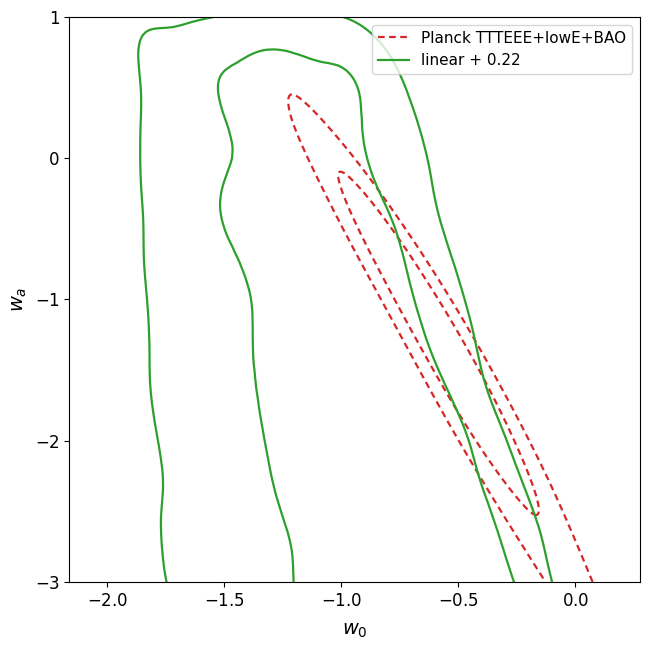

In [9]:
# pip install getdist matplotlib
import os
import numpy as np
from getdist.mcsamples import loadMCSamples, MCSamples
from getdist import plots

# ---------------- Planck 链（w0–wa 模型） ----------------
# 典型目录名为 base_w_wa；若你的目录名不同，改 planck_base_label
planck_base_dir   = "/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data"
planck_base_label = "base_w_wa"

planck_root_bao = os.path.join(
    planck_base_dir, planck_base_label,
    "plikHM_TTTEEE_lowl_lowE_BAO",
    f"{planck_base_label}_plikHM_TTTEEE_lowl_lowE_BAO"
)
# 若要带 CMB lensing，把上面 root 改为 *_post_lensing

# ---------------- 本地 3D 链（含 Ωm, w0, wa） ----------------
base_dir     = "/home/astrodust/SG/sgl_cosmo/GLS_cosmo01"
# local_pairs  = [("linear", "Tri"), ("linear", "0.22")]
local_pairs  = [("linear", "0.22")]
# 指明本地数组列索引：假设为 (Ωm, w0, wa) -> 分别是 0,1,2
local_col_idx = {'omegam': 0, 'w0': 1, 'wa': 2}
burnin_frac   = 0.30

# ---------------- 工具函数 ----------------
def ensure_w0_wa(samples):
    """
    确保 Planck 样本里有 w0 与 wa。
    部分 Planck 链把 w0 记作 w，这里自动映射成 w0。
    同时设置 GetDist 内部标签（不带 $）。
    """
    P = samples.getParams()
    names = {p.name for p in samples.getParamNames().names}

    # w0
    if 'w0' not in names:
        if hasattr(P, 'w'):
            samples.addDerived(P.w, name='w0', label=r'w_0')
        elif hasattr(P, 'w0'):
            pass
        else:
            raise RuntimeError("未在 Planck 链中找到 w 或 w0。请确认使用的是 w0–wa 模型链（如 base_w_wa）。")

    # wa
    if 'wa' not in names:
        if hasattr(P, 'wa'):
            pass
        else:
            raise RuntimeError("未在 Planck 链中找到 wa。请确认使用的是 w0–wa 模型链。")

    # 统一标签（GetDist 标签不要加 $）
    try: samples.setLabel('w0', r'w_0')
    except: pass
    try: samples.setLabel('wa', r'w_a')
    except: pass
    return samples

def numpy3d_to_mcsamples_w0wa(arr, burnin_frac=0.3, col_idx=None, label=None):
    """
    将本地 numpy 链 (可为 (nwalkers,nsteps,ndim) 或 (nsamp,ndim)) 提取 w0–wa，
    打包成 getdist.MCSamples。
    col_idx: {'omegam':i0,'w0':i1,'wa':i2}，只会用到 'w0' 和 'wa'。
    """
    if arr.ndim == 3:
        nwalk, nstep, ndim = arr.shape
        start = int(burnin_frac * nstep)
        flat = arr[:, start:, :].reshape(-1, ndim)
    else:
        flat = arr
        ndim = flat.shape[-1]

    i_w0 = col_idx['w0']
    i_wa = col_idx['wa']
    sub  = flat[:, [i_w0, i_wa]]  # 只要 (w0, wa)

    names  = ['w0', 'wa']          # 内部代号
    labels = [r'w_0', r'w_a']      # GetDist 标签（不带 $）
    mcs = MCSamples(samples=sub, names=names, labels=labels)
    if label:
        mcs.label = label
    return mcs

def auto_limits_multi(samples_list, name, q=(0.5, 99.5), pad=0.15):
    """汇总多组样本的分位数范围，返回统一坐标轴范围（增加边距）"""
    vals = []
    for s in samples_list:
        try:
            arr = getattr(s.getParams(), name)
            vals.append(np.percentile(arr, q))
        except Exception:
            pass
    if not vals:
        return None
    vals = np.array(vals)
    lo, hi = np.min(vals[:, 0]), np.max(vals[:, 1])
    w = hi - lo
    return lo - pad*w, hi + pad*w

# ---------------- 加载 Planck (TTTEEE+lowE+BAO) ----------------
planck_bao = loadMCSamples(planck_root_bao, settings={'ignore_rows': 0.3}, no_cache=True)
planck_bao = ensure_w0_wa(planck_bao)
planck_bao.label = r'Planck TTTEEE+lowE+BAO'

# ---------------- 加载本地 3D 链（linear + Tri / 0.22） ----------------
local_mcs = []
for evo, prior in local_pairs:
    f = os.path.join(base_dir, "Output", f"{evo}-{prior}", f"mcmc_cosmop3D-{evo}-{prior}.npy")
    if not os.path.isfile(f):
        raise FileNotFoundError(f"找不到本地链文件: {f}")
    arr = np.load(f)
    mcs = numpy3d_to_mcsamples_w0wa(arr, burnin_frac=burnin_frac,
                                    col_idx=local_col_idx,
                                    label=f"{evo} + {prior}")
    local_mcs.append(mcs)

# ---------------- 画 w0–wa，三套等高线 ----------------
all_samples = [planck_bao] + local_mcs
legend_labels = [s.label for s in all_samples]

colors = ['#d62728', '#2ca02c', '#9467bd']  # 红 / 绿 / 紫
line_args = [
    {'ls': '--', 'lw': 1.6},  # Planck + BAO
    {'ls': '-',  'lw': 1.6},  # linear + Tri
    {'ls': '-.', 'lw': 1.6},  # linear + 0.22
]

g = plots.get_subplot_plotter(width_inch=6.6)
g.settings.num_plot_contours = 2
g.settings.axes_fontsize = 12
g.settings.legend_fontsize = 11

g.plot_2d(
    all_samples,
    ['w0', 'wa'],
    filled=False,
    colors=colors,
    line_args=line_args,
    legend_labels=legend_labels,
)

# 坐标轴范围与标签（Matplotlib 端加 $...$）
ax = g.subplots[0, 0]
xlim = auto_limits_multi(all_samples, 'w0') or (-2.5, -0.3)
# ylim = auto_limits_multi(all_samples, 'wa') or (-2.5, 2.5)
ylim = (-3, 1.)
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r'$w_0$')
ax.set_ylabel(r'$w_a$')

g.add_legend(legend_labels,
             legend_loc='upper right', colored_text=False)

out = "combined_w0_wa_planckBAO_vs_local3D.png"
g.export(out)
print(f"Saved: {out}")


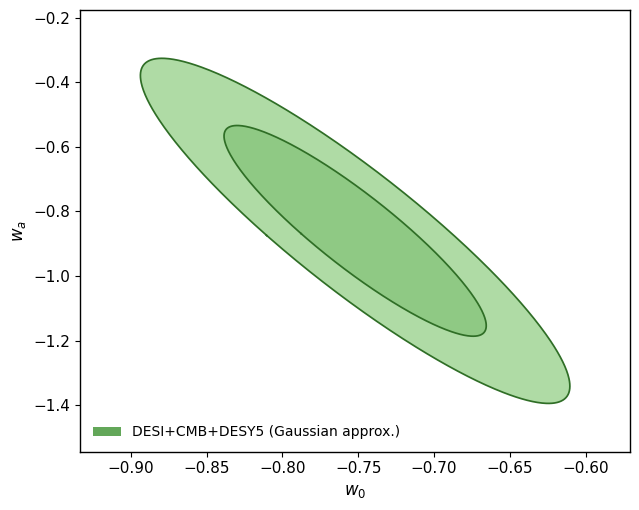

array([[ 0.003249 , -0.0110295],
       [-0.0110295,  0.046225 ]])

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def plot_gaussian_contour(
    mu, sigmas, rho=-0.9,
    levels=(2.30, 6.17),
    facecolors=("#3c9130", "#9bd28f"),
    edgecolor="#2f6e26",
    fill=True,
    label=None,
    figsize=(6.2, 5.0),
    pad_frac=0.12,         # 按最大椭圆的宽/高扩展边界
    aspect="auto",         # 不再强制等比例
    ref_lines=(-1.0, 0.0), # 参考虚线：x=-1, y=0
    rc_update=True
):
    """
    用二维高斯近似在 (w0, wa) 平面画 68%/95% 等高线，自动设置坐标范围与留白。
    返回：cov 协方差矩阵
    """
    if rc_update:
        plt.rcParams.update({
            "axes.labelsize": 12, "xtick.labelsize": 11,
            "ytick.labelsize": 11, "legend.fontsize": 10,
            "axes.linewidth": 1.0
        })

    mu = np.asarray(mu, dtype=float)
    s0, sa = sigmas
    cov = np.array([[s0**2, rho*s0*sa],
                    [rho*s0*sa, sa**2]], dtype=float)

    # 特征分解：Σ = R Λ R^T
    evals, evecs = np.linalg.eigh(cov)         # (2,), (2×2)
    theta = np.linspace(0, 2*np.pi, 600)
    unit  = np.vstack((np.cos(theta), np.sin(theta)))  # (2, N)

    # 预计算所有等高线的点，最大层用于自适应边界
    ell_list = []
    for lev in levels:
        radii = np.sqrt(lev * evals)[:, None]  # (2,1)
        ell   = (evecs @ (radii * unit)).T + mu  # (N,2)
        ell_list.append(ell)

    # —— 自动边界（按最大等高线）——
    x_all, y_all = ell_list[-1][:,0], ell_list[-1][:,1]
    xspan = x_all.max() - x_all.min()
    yspan = y_all.max() - y_all.min()
    xlim = (x_all.min() - pad_frac*xspan, x_all.max() + pad_frac*xspan)
    ylim = (y_all.min() - pad_frac*yspan, y_all.max() + pad_frac*yspan)

    # —— 画图 —— 
    fig, ax = plt.subplots(figsize=figsize)

    # facecolors 长度与 levels 对齐
    if not fill:
        fcs = [None]*len(levels)
    else:
        fcs = (list(facecolors) + [facecolors[-1]]*len(levels))[:len(levels)]

    for ell, fc in zip(ell_list, fcs):
        if fill and fc is not None:
            ax.fill(ell[:,0], ell[:,1], fc, alpha=0.8, ec="none")
        ax.plot(ell[:,0], ell[:,1], color=edgecolor, lw=1.25)

    # 参考虚线（只在范围内才画）
    if ref_lines is not None:
        xref, yref = ref_lines
        if xlim[0] < xref < xlim[1]:
            ax.axvline(xref, ls="--", lw=1.0, color="gray")
        if ylim[0] < yref < ylim[1]:
            ax.axhline(yref, ls="--", lw=1.0, color="gray")

    ax.set_xlabel(r"$w_0$")
    ax.set_ylabel(r"$w_a$")
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.set_aspect(aspect)  # "auto" 默认更宽松
    if label:
        ax.legend([label], frameon=False, loc="lower left")
    plt.tight_layout()
    plt.show()
    return cov

# —— 使用示例 —— #
mu = (-0.752, -0.86)
sigmas = (0.057, 0.215)
plot_gaussian_contour(mu, sigmas, rho=-0.90,
                      label="DESI+CMB+DESY5 (Gaussian approx.)",
                      figsize=(6.5, 5.2), pad_frac=0.14, aspect="auto")


Removed no burn in


/tmp/ipykernel_199070/1156485350.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


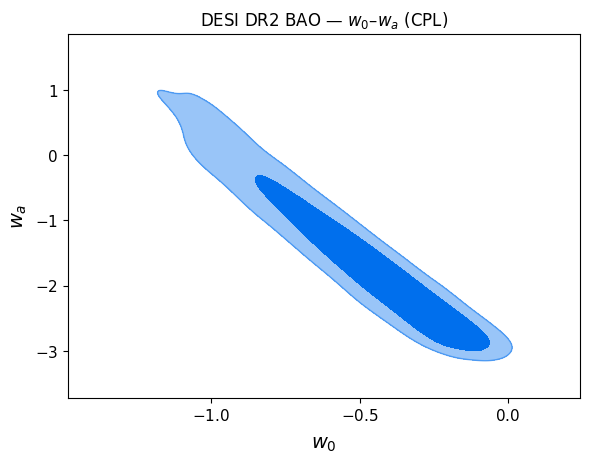

In [12]:
# pip install getdist matplotlib
import glob
import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples

# ---- path to your chain parts (edit if needed)
folder = r"/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/DESI_BAO_base_w_wa/desi-bao-all"
files  = sorted(glob.glob(f"{folder}/chain.*.txt"))
if not files:
    raise FileNotFoundError("No chain.*.txt found under " + folder)

# Read each part; header lines start with '#'
parts = [np.genfromtxt(f, names=True, comments="#") for f in files]
data  = np.concatenate(parts)  # structured array

def getcol(a, *candidates):
    for name in candidates:
        if name in a.dtype.names:
            return a[name]
    return None

# ---- pull w0, wa (try a few common names)
w0 = getcol(data, "w")
wa = getcol(data, "wa", "w_a", "wprime", "w_a_cpl")

if w0 is None:
    # sometimes a constant-w chain uses 'w' — but we need w0 specifically
    alt_w = getcol(data, "w")
    if alt_w is not None:
        raise KeyError("Found 'w' (constant-w) but need 'w0' for w0–wa analysis.")
    raise KeyError("Could not find 'w0' in columns.")

if wa is None:
    raise KeyError("Could not find 'wa' in columns.")

# ---- build GetDist sample with (w0, wa)
samples = np.vstack([w0, wa]).T

gd = MCSamples(
    samples=samples,
    names=["w0", "wa"],
    labels=[r"w_0", r"w_a"],  # no $ here; GetDist adds math rendering
)
gd.updateSettings({'ignore_rows': 0.0})  # keep all rows; adjust if you want burn-in cut

# ---- plot w0–wa 2D contours
g = plots.get_single_plotter()
g.plot_2d(gd, "w0", "wa", filled=True)
plt.title(r"DESI DR2 BAO — $w_0$–$w_a$ (CPL)")
plt.xlabel(r"$w_0$")
plt.ylabel(r"$w_a$")
plt.tight_layout()
plt.show()


/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_2.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_3.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_1.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_4.txt
Removed no burn in
Removed no burn in


/tmp/ipykernel_199070/1958665109.py:195: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: combined_w0_wa_planckBAO_local_with_DESI.png
DESI cov=
[[ 0.003249  -0.0110295]
 [-0.0110295  0.046225 ]]


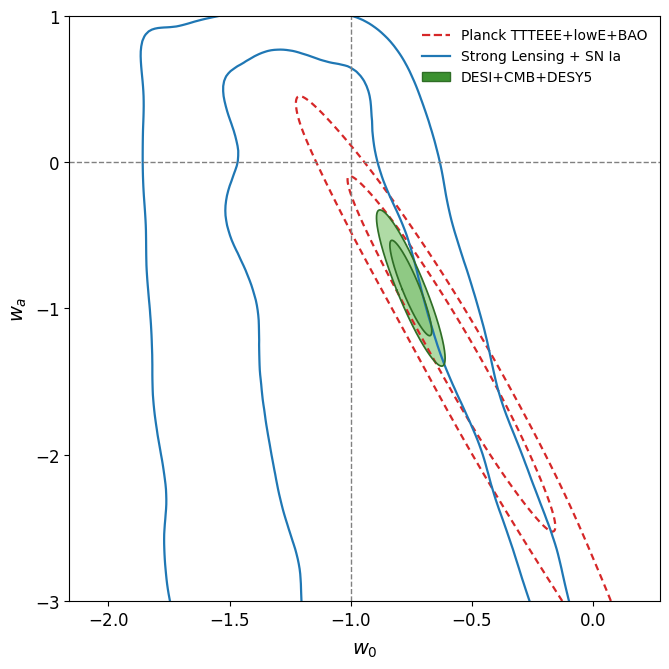

In [1]:
# pip install getdist matplotlib
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from getdist.mcsamples import loadMCSamples, MCSamples
from getdist import plots

# =====================  工具函数  =====================

def ensure_w0_wa(samples):
    P = samples.getParams()
    names = {p.name for p in samples.getParamNames().names}
    if 'w0' not in names:
        if hasattr(P, 'w'):
            samples.addDerived(P.w, name='w0', label=r'w_0')
        elif hasattr(P, 'w0'):
            pass
        else:
            raise RuntimeError("未在 Planck 链中找到 w 或 w0。请确认是 w0–wa 模型。")
    if 'wa' not in names:
        if hasattr(P, 'wa'):
            pass
        else:
            raise RuntimeError("未在 Planck 链中找到 wa。请确认是 w0–wa 模型。")
    try: samples.setLabel('w0', r'w_0')
    except: pass
    try: samples.setLabel('wa', r'w_a')
    except: pass
    return samples

def numpy3d_to_mcsamples_w0wa(arr, burnin_frac=0.3, col_idx=None, label=None):
    if arr.ndim == 3:
        nwalk, nstep, ndim = arr.shape
        start = int(burnin_frac * nstep)
        flat = arr[:, start:, :].reshape(-1, ndim)
    else:
        flat = arr
    i_w0 = col_idx['w0']; i_wa = col_idx['wa']
    sub  = flat[:, [i_w0, i_wa]]
    names  = ['w0', 'wa']; labels = [r'w_0', r'w_a']
    mcs = MCSamples(samples=sub, names=names, labels=labels)
    if label: mcs.label = label
    return mcs

def auto_limits_multi(samples_list, name, q=(0.5, 99.5), pad=0.15):
    vals = []
    for s in samples_list:
        try:
            arr = getattr(s.getParams(), name)
            vals.append(np.percentile(arr, q))
        except Exception:
            pass
    if not vals:
        return None
    vals = np.array(vals)
    lo, hi = np.min(vals[:, 0]), np.max(vals[:, 1])
    w = hi - lo
    return lo - pad*w, hi + pad*w

# —— 在既有 Axes 上叠加 DESI 的二维高斯等高线（绿色） ——
def draw_desi_gaussian_on_ax(
    ax, mu, sigmas, rho=-0.90,
    levels=(2.30, 6.17),
    facecolors=("#3c9130", "#9bd28f"),  # 深/浅绿
    edgecolor="#2f6e26",
    label="DESI+CMB+DESY5 (Gaussian approx.)",
    return_extent=True
):
    mu = np.asarray(mu, dtype=float)
    s0, sa = sigmas
    cov = np.array([[s0**2, rho*s0*sa],
                    [rho*s0*sa, sa**2]], dtype=float)

    evals, evecs = np.linalg.eigh(cov)
    th   = np.linspace(0, 2*np.pi, 600)
    unit = np.vstack((np.cos(th), np.sin(th)))             # (2,N)

    ell_list = []
    for lev, fc in zip(levels, facecolors):
        radii = np.sqrt(lev * evals)[:, None]              # (2,1)
        ell   = (evecs @ (radii * unit)).T + mu            # (N,2)
        ell_list.append(ell)
        ax.fill(ell[:,0], ell[:,1], fc, alpha=0.8, ec="none")
        ax.plot(ell[:,0], ell[:,1], color=edgecolor, lw=1.25)

    # 最大等高线用于给外部做边界合并
    if return_extent:
        x_all, y_all = ell_list[-1][:,0], ell_list[-1][:,1]
        return cov, (x_all.min(), x_all.max(), y_all.min(), y_all.max())
    return cov, None

# =====================  输入：Planck 链与本地链  =====================

# --- Planck 链（w0–wa 模型）
planck_base_dir   = "/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data"
planck_base_label = "base_w_wa"
planck_root_bao = os.path.join(
    planck_base_dir, planck_base_label,
    "plikHM_TTTEEE_lowl_lowE_BAO",
    f"{planck_base_label}_plikHM_TTTEEE_lowl_lowE_BAO"
)
planck_bao = loadMCSamples(planck_root_bao, settings={'ignore_rows': 0.3}, no_cache=True)
planck_bao = ensure_w0_wa(planck_bao)
planck_bao.label = r'Planck TTTEEE+lowE+BAO'

# --- 本地 3D 链（含 Ωm, w0, wa）
base_dir       = "/home/astrodust/SG/sgl_cosmo/GLS_cosmo01"
local_pairs    = [("linear", "0.22")]   # 可加 ("linear","Tri")
local_col_idx  = {'omegam': 0, 'w0': 1, 'wa': 2}
burnin_frac    = 0.30

local_mcs = []
for evo, prior in local_pairs:
    f = os.path.join(base_dir, "Output", f"{evo}-{prior}", f"mcmc_cosmop3D-{evo}-{prior}.npy")
    if not os.path.isfile(f):
        raise FileNotFoundError(f"找不到本地链文件: {f}")
    arr = np.load(f)
    mcs = numpy3d_to_mcsamples_w0wa(arr, burnin_frac=burnin_frac,
                                    col_idx=local_col_idx,
                                    label=r"Strong Lensing + SN Ia")
    local_mcs.append(mcs)

# =====================  画图（GetDist + DESI 叠加）  =====================

all_samples   = [planck_bao] + local_mcs
legend_labels = [s.label for s in all_samples]

# 注意：避免与 DESI 冲突，这里不要用绿色
colors   = ['#d62728', '#1f77b4', '#9467bd', '#8c564b'][:len(all_samples)]
line_args = [{'ls': '--', 'lw': 1.6}] + [{'ls': '-', 'lw': 1.6} for _ in local_mcs]

g = plots.get_subplot_plotter(width_inch=6.8)
g.settings.num_plot_contours = 2
g.settings.axes_fontsize = 12
g.settings.legend_fontsize = 11

# 先画 Planck / 本地链（空心等高线）
g.plot_2d(
    all_samples,
    ['w0', 'wa'],
    filled=False,
    colors=colors[:len(all_samples)],
    line_args=line_args,
    legend_labels=None,  # 我们用自定义 legend，包含 DESI
)

ax = g.subplots[0, 0]

# —— 叠加 DESI+CMB+DESY5（绿色填充的二维高斯近似） ——
mu_desi     = (-0.752, -0.86)
sigma_desi  = (0.057, 0.215)   # 对称化 σ_wa
rho_desi    = -0.90            # 可微调以匹配倾角
cov_desi, extent = draw_desi_gaussian_on_ax(ax, mu_desi, sigma_desi, rho=rho_desi,
                                            label="DESI+CMB+DESY5 (Gaussian approx.)")

# —— 自适应坐标范围：合并 GetDist 的范围与 DESI 的范围 ——
xlim_data = auto_limits_multi(all_samples, 'w0')
ylim_data = auto_limits_multi(all_samples, 'wa')
if extent is not None:
    xmin, xmax, ymin, ymax = extent
    if xlim_data is None: xlim_data = (xmin, xmax)
    else: xlim_data = (min(xlim_data[0], xmin), max(xlim_data[1], xmax))
    if ylim_data is None: ylim_data = (ymin, ymax)
    else: ylim_data = (min(ylim_data[0], ymin), max(ylim_data[1], ymax))

# 若想固定上边界更像官方图，可手设 ylim_top=0.2
# ylim_top = 0.2
# if ylim_data is None:
#     ylim = (-3.0, ylim_top)
# else:
#     ylim = (min(-3.0, ylim_data[0]), min(ylim_top, ylim_data[1]))
ylim = (-3, 1.)
ax.set_xlim(*(xlim_data or (-1.2, -0.45)))
ax.set_ylim(*ylim)

# 轴标签 + 参考虚线
ax.set_xlabel(r'$w_0$')
ax.set_ylabel(r'$w_a$')
ax.axvline(-1.0, ls="--", lw=1.0, color="gray")
ax.axhline(0.0,  ls="--", lw=1.0, color="gray")

# —— 自定义图例：包含 GetDist 线型与 DESI 绿色块 ——
handles = []
# GetDist 数据集
for col, la, lab in zip(colors[:len(all_samples)], line_args, [s.label for s in all_samples]):
    handles.append(Line2D([0], [0], color=col, lw=la.get('lw', 1.6),
                          ls=la.get('ls', '-'), label=lab))
# DESI 填充块（绿色）
handles.append(Patch(facecolor="#3c9130", edgecolor="#2f6e26",
                     label="DESI+CMB+DESY5"))
ax.legend(handles=handles, frameon=False, loc='upper right')

plt.tight_layout()
out = "combined_w0_wa_planckBAO_local_with_DESI.png"
g.export(out)
print(f"Saved: {out}\nDESI cov=\n{cov_desi}")


/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_2.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_3.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_1.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_4.txt
Removed no burn in
Removed no burn in
Removed no burn in


/tmp/ipykernel_199070/2379525946.py:234: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: combined_w0_wa_planckBAO_local_with_DESI_and_JOINT.png
Joint added as purple dashed curve.


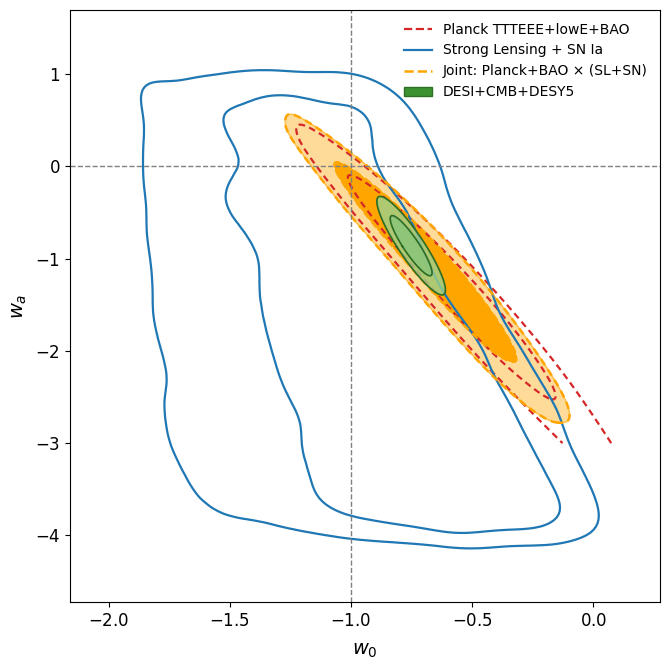

In [7]:
# pip install getdist matplotlib scipy
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from getdist.mcsamples import loadMCSamples, MCSamples
from getdist import plots

# ======== NEW: for KDE reweighting ========
from scipy.stats import gaussian_kde

def _extract_2d_from_mcs(mcs, xname='w0', yname='wa'):
    P = mcs.getParams()
    x = getattr(P, xname)
    y = getattr(P, yname)
    return np.vstack([x, y]).T  # (N,2)

def make_joint_planckbao_times_local(planck_bao_mcs, local_mcs, label=r'Joint: Planck+BAO × (SL+SN)', bw='scott'):
    """
    用 local_mcs 的 (w0, wa) KDE 在 planck_bao_mcs 的样本点上评估密度，作为附加权重 → 联合后验。
    假设两者对 (w0, wa) 的先验一致或近似均匀；若不同需在此做先验校正。
    """
    base_pts = _extract_2d_from_mcs(planck_bao_mcs, 'w0', 'wa')        # Planck+BAO 样本点
    ref_pts  = _extract_2d_from_mcs(local_mcs,        'w0', 'wa')      # SL+SN 样本点

    kde  = gaussian_kde(ref_pts.T, bw_method=bw)
    dens = kde(base_pts.T)                                             # 估计 p(theta | SL+SN)
    dens = np.clip(dens, 1e-300, None)                                 # 数值稳定

    w_base  = planck_bao_mcs.weights if planck_bao_mcs.weights is not None else np.ones(base_pts.shape[0])
    w_joint = w_base * dens

    joint = MCSamples(samples=base_pts, names=['w0','wa'], labels=[r'w_0', r'w_a'], weights=w_joint)
    joint.label = label
    return joint
# =========================================

# =====================  工具函数（原有）  =====================
def ensure_w0_wa(samples):
    P = samples.getParams()
    names = {p.name for p in samples.getParamNames().names}
    if 'w0' not in names:
        if hasattr(P, 'w'):
            samples.addDerived(P.w, name='w0', label=r'w_0')
        elif hasattr(P, 'w0'):
            pass
        else:
            raise RuntimeError("未在 Planck 链中找到 w 或 w0。请确认是 w0–wa 模型。")
    if 'wa' not in names:
        if hasattr(P, 'wa'):
            pass
        else:
            raise RuntimeError("未在 Planck 链中找到 wa。请确认是 w0–wa 模型。")
    try: samples.setLabel('w0', r'w_0')
    except: pass
    try: samples.setLabel('wa', r'w_a')
    except: pass
    return samples

def numpy3d_to_mcsamples_w0wa(arr, burnin_frac=0.3, col_idx=None, label=None):
    if arr.ndim == 3:
        nwalk, nstep, ndim = arr.shape
        start = int(burnin_frac * nstep)
        flat = arr[:, start:, :].reshape(-1, ndim)
    else:
        flat = arr
    i_w0 = col_idx['w0']; i_wa = col_idx['wa']
    sub  = flat[:, [i_w0, i_wa]]
    names  = ['w0', 'wa']; labels = [r'w_0', r'w_a']
    mcs = MCSamples(samples=sub, names=names, labels=labels)
    if label: mcs.label = label
    return mcs

def auto_limits_multi(samples_list, name, q=(0.5, 99.5), pad=0.15):
    vals = []
    for s in samples_list:
        try:
            arr = getattr(s.getParams(), name)
            vals.append(np.percentile(arr, q))
        except Exception:
            pass
    if not vals:
        return None
    vals = np.array(vals)
    lo, hi = np.min(vals[:, 0]), np.max(vals[:, 1])
    w = hi - lo
    return lo - pad*w, hi + pad*w

# —— 在既有 Axes 上叠加 DESI 的二维高斯等高线（绿色） ——
def draw_desi_gaussian_on_ax(
    ax, mu, sigmas, rho=-0.90,
    levels=(2.30, 6.17),
    facecolors=("#3c9130", "#9bd28f"),
    edgecolor="#2f6e26",
    label="DESI+CMB+DESY5 (Gaussian approx.)",
    return_extent=True,
    zorder=20,                 # ← 新增：整体图层
):
    mu = np.asarray(mu, dtype=float)
    s0, sa = sigmas
    cov = np.array([[s0**2, rho*s0*sa],
                    [rho*s0*sa, sa**2]], dtype=float)

    import numpy.linalg as npl
    evals, evecs = npl.eigh(cov)
    th   = np.linspace(0, 2*np.pi, 600)
    unit = np.vstack((np.cos(th), np.sin(th)))

    ell_list = []
    for lev, fc in zip(levels, facecolors):
        radii = np.sqrt(lev * evals)[:, None]
        ell   = (evecs @ (radii * unit)).T + mu
        ell_list.append(ell)
        ax.fill(ell[:,0], ell[:,1], fc, alpha=0.8, ec="none", zorder=zorder)   # ← 这里
        ax.plot(ell[:,0], ell[:,1], color=edgecolor, lw=1.25, zorder=zorder+0.1)
    if return_extent:
        x_all, y_all = ell_list[-1][:,0], ell_list[-1][:,1]
        return cov, (x_all.min(), x_all.max(), y_all.min(), y_all.max())
    return cov, None


# =====================  输入：Planck 链与本地链  =====================

# --- Planck 链（w0–wa 模型）
planck_base_dir   = "/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data"
planck_base_label = "base_w_wa"
planck_root_bao = os.path.join(
    planck_base_dir, planck_base_label,
    "plikHM_TTTEEE_lowl_lowE_BAO",
    f"{planck_base_label}_plikHM_TTTEEE_lowl_lowE_BAO"
)
planck_bao = loadMCSamples(planck_root_bao, settings={'ignore_rows': 0.3}, no_cache=True)
planck_bao = ensure_w0_wa(planck_bao)
planck_bao.label = r'Planck TTTEEE+lowE+BAO'

# --- 本地 3D 链（含 Ωm, w0, wa）
base_dir       = "/home/astrodust/SG/sgl_cosmo/GLS_cosmo01"
local_pairs    = [("linear", "0.22")]   # 可加 ("linear","Tri")
local_col_idx  = {'omegam': 0, 'w0': 1, 'wa': 2}
burnin_frac    = 0.30

local_mcs = []
for evo, prior in local_pairs:
    f = os.path.join(base_dir, "Output", f"{evo}-{prior}", f"mcmc_cosmop3D-{evo}-{prior}.npy")
    if not os.path.isfile(f):
        raise FileNotFoundError(f"找不到本地链文件: {f}")
    arr = np.load(f)
    mcs = numpy3d_to_mcsamples_w0wa(arr, burnin_frac=burnin_frac,
                                    col_idx=local_col_idx,
                                    label=r"Strong Lensing + SN Ia")
    local_mcs.append(mcs)

# ======== NEW: 构造联合后验 Joint: Planck+BAO × (SL+SN)（紫色虚线，不填充） ========
joint_planck_bao = make_joint_planckbao_times_local(
    planck_bao_mcs = planck_bao,
    local_mcs      = local_mcs[0],
    label          = r'Joint: Planck+BAO × (SL+SN)',
    bw             = 'scott'    # 可试 'silverman' 或数值带宽（如 0.15）
)
# ======================================================================

# =====================  画图（GetDist + DESI 叠加）  =====================

# 将联合后验加入队列
all_samples   = [planck_bao] + local_mcs + [joint_planck_bao]
legend_labels = [s.label for s in all_samples]

# 颜色与线型：Planck 红实线、SL+SN 蓝实线、Joint 紫色虚线
COL_RED   = '#d62728'
COL_BLUE  = '#1f77b4'
COL_PURP  = 'orange'  # 
colors    = [COL_RED, COL_BLUE, COL_PURP]
line_args = [{'ls': '--', 'lw': 1.6},   # Planck+BAO（你原设为虚线）
             {'ls': '-',  'lw': 1.6},   # SL+SN
             {'ls': '--', 'lw': 1.8}]   # Joint: 紫色虚线（不填充）

g = plots.get_subplot_plotter(width_inch=6.8)
g.settings.num_plot_contours = 2
g.settings.axes_fontsize = 12
g.settings.legend_fontsize = 11

# 画三条空心等高线（不填充）
g.plot_2d(
    all_samples,
    ['w0', 'wa'],
    filled=False,
    colors=colors[:len(all_samples)],
    line_args=line_args,
    legend_labels=None,  # 自定义 legend
)
g.plot_2d(joint_planck_bao,['w0', 'wa'], filled=True, colors=[COL_PURP], add_legend_proxy=False, alpha=0.3)

ax = g.subplots[0, 0]

# —— 叠加 DESI+CMB+DESY5（绿色填充的二维高斯近似） ——
mu_desi     = (-0.752, -0.86)
sigma_desi  = (0.057, 0.215)
rho_desi    = -0.90
cov_desi, extent = draw_desi_gaussian_on_ax(ax, mu_desi, sigma_desi, rho=rho_desi,
                                            label="DESI+CMB+DESY5 (Gaussian approx.)",zorder=20)

# —— 自适应坐标范围：合并 GetDist 与 DESI 的范围 ——
xlim_data = auto_limits_multi(all_samples, 'w0')
ylim_data = auto_limits_multi(all_samples, 'wa')
if extent is not None:
    xmin, xmax, ymin, ymax = extent
    if xlim_data is None: xlim = (xmin, xmax)
    else: xlim = (min(xlim_data[0], xmin), max(xlim_data[1], xmax))
    if ylim_data is None: ylim = (ymin, ymax)
    else: ylim = (min(ylim_data[0], ymin), max(ylim_data[1], ymax))
else:
    xlim = xlim_data or (-1.2, -0.45)
    ylim = ylim_data or (-3.0, 1.0)

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)

# 轴标签 + 参考虚线
ax.set_xlabel(r'$w_0$')
ax.set_ylabel(r'$w_a$')
ax.axvline(-1.0, ls="--", lw=1.0, color="gray")
ax.axhline(0.0,  ls="--", lw=1.0, color="gray")

# —— 自定义图例（含联合紫色虚线与 DESI 绿色块） ——
handles = []
for col, la, lab in zip(colors[:len(all_samples)], line_args, [s.label for s in all_samples]):
    handles.append(Line2D([0], [0], color=col, lw=la.get('lw', 1.6),
                          ls=la.get('ls', '-'), label=lab))
handles.append(Patch(facecolor="#3c9130", edgecolor="#2f6e26",
                     label="DESI+CMB+DESY5"))
ax.legend(handles=handles, frameon=False, loc='upper right')

plt.tight_layout()
out = "combined_w0_wa_planckBAO_local_with_DESI_and_JOINT.png"
g.export(out)
print(f"Saved: {out}\nJoint added as purple dashed curve.")


Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Saved plot: w0_wa_SL_BAO_SLxBAO_DESIcombo.png


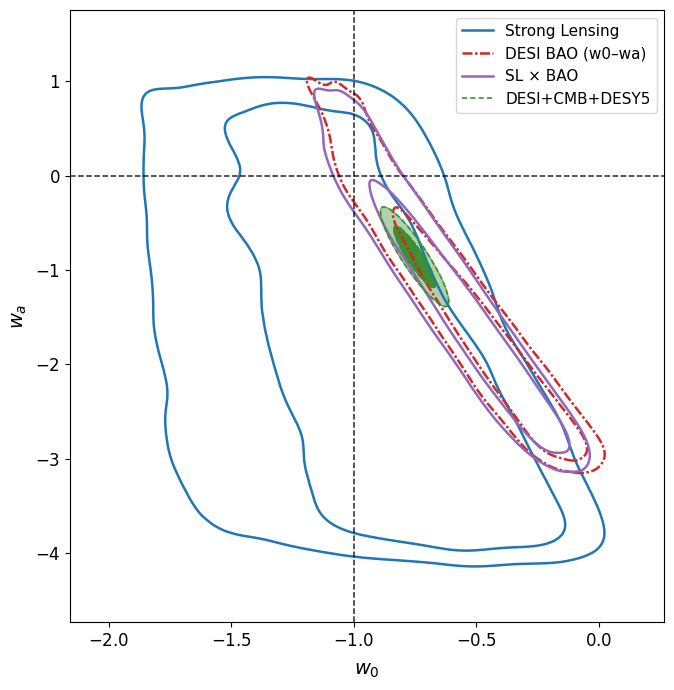

In [21]:
# === 代码块①：绘制 (w0, wa) 四组等高线：SL（实）、BAO（-.）、SL+BAO（实）、DESI+CMB+DESY5（填充） ===
# pip install getdist matplotlib scipy
import os, glob
import numpy as np
import matplotlib.pyplot as plt
from getdist.mcsamples import MCSamples
from getdist import plots
from scipy.stats import gaussian_kde

# ====================== 基础路径（按需修改） ======================
base_dir       = "/home/astrodust/SG/sgl_cosmo/GLS_cosmo01"
local_pairs    = [("linear", "0.22")]      # 本地 3D 链（含 Ωm, w0, wa）
local_col_idx  = {'omegam': 0, 'w0': 1, 'wa': 2}
burnin_frac    = 0.30

# DESI BAO (w0–wa) 文本链目录（含 chain.*.txt）
desi_bao_folder = r"/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/DESI_BAO_base_w_wa/desi-bao-all"

# DESI+CMB+DESY5 的二维高斯“摘要”（用于第四组填充）
mu_desi     = (-0.752, -0.86)   # (w0, wa)
sigma_desi  = (0.057, 0.215)    # (σ_w0, σ_wa)
rho_desi    = -0.90

# ====================== 工具函数：加载/派生 ======================
def numpy3d_to_mcsamples_w0wa(arr, burnin_frac=0.3, col_idx=None, label=None):
    if arr.ndim == 3:
        nwalk, nstep, ndim = arr.shape
        start = int(burnin_frac * nstep)
        flat = arr[:, start:, :].reshape(-1, ndim)
    else:
        flat = arr
    i_w0 = col_idx['w0']; i_wa = col_idx['wa']
    sub  = flat[:, [i_w0, i_wa]]
    mcs = MCSamples(samples=sub, names=['w0','wa'], labels=[r'w_0', r'w_a'])
    if label: mcs.label = label
    return mcs

def auto_limits_multi(samples_list, name, q=(0.5, 99.5), pad=0.15):
    vals = []
    for s in samples_list:
        try:
            arr = getattr(s.getParams(), name)
            vals.append(np.percentile(arr, q))
        except Exception:
            pass
    if not vals:
        return None
    vals = np.array(vals)
    lo, hi = np.min(vals[:, 0]), np.max(vals[:, 1])
    w = hi - lo
    return lo - pad*w, hi + pad*w

def _extract_2d_from_mcs(mcs, xname='w0', yname='wa'):
    P = mcs.getParams()
    x = getattr(P, xname)
    y = getattr(P, yname)
    return np.vstack([x, y]).T

def make_joint_by_kde(base_mcs, ref_pts, label, bw='scott'):
    """
    用 ref_pts(N,2) 的 KDE 在 base_mcs 的 (w0, wa) 点上评估密度，作为附加权重 → 联合后验。
    假设两者对 (w0, wa) 的先验一致或近似均匀；若不同需在此做先验校正。
    """
    base_pts = _extract_2d_from_mcs(base_mcs, 'w0', 'wa')
    w_base   = base_mcs.weights if base_mcs.weights is not None else np.ones(base_pts.shape[0])
    kde  = gaussian_kde(ref_pts.T, bw_method=bw)
    dens = np.clip(kde(base_pts.T), 1e-300, None)
    w_joint = w_base * dens
    joint = MCSamples(samples=base_pts, names=['w0','wa'], labels=[r'w_0', r'w_a'], weights=w_joint)
    joint.label = label
    return joint

def _getcol(a, *candidates):
    for name in candidates:
        if name in a.dtype.names:
            return a[name]
    return None

def load_desi_bao_w0wa(folder, label=r"DESI BAO (w0–wa)"):
    """读取 DESI BAO (w0–wa) 文本链（chain.*.txt），返回仅含 (w0, wa) 的 MCSamples。"""
    files  = sorted(glob.glob(os.path.join(folder, "chain.*.txt")))
    if not files:
        raise FileNotFoundError("No chain.*.txt found under " + folder)
    parts = [np.genfromtxt(f, names=True, comments="#") for f in files]
    data  = np.concatenate(parts)
    w0 = _getcol(data, "w0", "w", "w_0")
    wa = _getcol(data, "wa", "w_a", "wprime", "w_a_cpl")
    if w0 is None or wa is None:
        raise KeyError("DESI: need columns 'w0' and 'wa'（兼容别名：w / w_0, w_a / wprime / w_a_cpl）.")
    weights = _getcol(data, "weight", "weights", "Weight", "Weights")
    samples = np.vstack([w0, wa]).T
    gd = MCSamples(samples=samples, names=["w0","wa"], labels=[r"w_0", r"w_a"],
                   weights=weights if weights is not None else None)
    gd.updateSettings({'ignore_rows': 0.0})
    gd.label = label
    return gd

def gaussian_to_mcsamples_w0wa(mu, sigmas, rho, nsamp=200000, seed=42, label="DESI+CMB+DESY5"):
    """将 (mu, sigmas, rho) 的二维高斯近似采样为 MCSamples，便于绘图与统计。"""
    rng = np.random.default_rng(seed)
    s0, sa = sigmas
    cov = np.array([[s0**2, rho*s0*sa],
                    [rho*s0*sa, sa**2]], dtype=float)
    samples = rng.multivariate_normal(mean=mu, cov=cov, size=nsamp)
    mcs = MCSamples(samples=samples, names=['w0','wa'], labels=[r'w_0', r'w_a'])
    mcs.updateSettings({'ignore_rows':0.0})
    mcs.label = label
    return mcs

# ====================== 加载数据 ======================
# 本地 SL（含 w0, wa）
local_mcs = []
for evo, prior in local_pairs:
    f = os.path.join(base_dir, "Output", f"{evo}-{prior}", f"mcmc_cosmop3D-{evo}-{prior}.npy")
    if not os.path.isfile(f):
        raise FileNotFoundError(f"找不到本地链文件: {f}")
    arr = np.load(f)
    mcs = numpy3d_to_mcsamples_w0wa(arr, burnin_frac=burnin_frac, col_idx=local_col_idx,
                                    label=r"Strong Lensing")
    local_mcs.append(mcs)
SL = local_mcs[0]

# DESI BAO（w0–wa）
BAO = load_desi_bao_w0wa(desi_bao_folder, label=r"DESI BAO (w0–wa)")

# DESI+CMB+DESY5 高斯近似 → 样本（此组需要填充）
DESI_CMB_DESY5 = gaussian_to_mcsamples_w0wa(mu_desi, sigma_desi, rho_desi,
                                            nsamp=200000, seed=123, label=r"DESI+CMB+DESY5")

# ====================== 联合限制（KDE 重加权） ======================
SL_pts = _extract_2d_from_mcs(SL, 'w0', 'wa')

# SL + BAO
SLxBAO = make_joint_by_kde(
    base_mcs=BAO,
    ref_pts=SL_pts,
    label=r"SL × BAO",
    bw='scott'
)

# ====================== 画 w0–wa：四组 ======================
to_plot = [SL, BAO, SLxBAO, DESI_CMB_DESY5]
legend_labels = [s.label for s in to_plot]

# 颜色和线型：BAO 用 -.; SL 与 SL+BAO 用实线；DESI+CMB+DESY5 仅填充
COL_SL     = '#1f77b4'  # 蓝（实线）
COL_BAO    = '#d62728'  # 红（-.）
COL_SLBAO  = '#9467bd'  # 紫（实线）
COL_DESIC  = '#3c9130'  # 绿（填充用）

colors    = [COL_SL,  COL_BAO,  COL_SLBAO, COL_DESIC]
line_args = [
    {'ls': '-',  'lw': 1.8},   # SL
    {'ls': '-.', 'lw': 1.8},   # BAO
    {'ls': '-',  'lw': 1.8},   # SL+BAO
    {'ls': '--', 'lw': 1.2},   # DESI+CMB+DESY5（只做轮廓占位，不填充；稍细）
]

g = plots.get_subplot_plotter(width_inch=7.0)
g.settings.num_plot_contours = 2
g.settings.axes_fontsize = 12
g.settings.legend_fontsize = 11

# 不填充等高线（四组都先画轮廓；但稍后只对 DESI+CMB+DESY5 填充）
g.plot_2d(
    to_plot,
    ['w0', 'wa'],
    filled=False,
    colors=colors,
    line_args=line_args,
    legend_labels=None,
)

# 仅对 DESI+CMB+DESY5 填充
g.plot_2d(DESI_CMB_DESY5, ['w0', 'wa'], filled=True,
          colors=[COL_DESIC], add_legend_proxy=False, alpha=0.30)

ax = g.subplots[0, 0]
xlim = auto_limits_multi(to_plot, 'w0') or (-1.4, -0.5)
ylim = auto_limits_multi(to_plot, 'wa') or (-3.0, 1.0)
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r'$w_0$')
ax.set_ylabel(r'$w_a$')

# 参考虚线
ax.axvline(-1.0, ls='--', lw=1.1, color='k', alpha=0.85)
ax.axhline(0.0,  ls='--', lw=1.1, color='k', alpha=0.85)

g.add_legend(legend_labels, legend_loc='upper right', colored_text=False)

out = "w0_wa_SL_BAO_SLxBAO_DESIcombo.png"
g.export(out)
print(f"Saved plot: {out}")


Removed no burn in
Removed no burn in
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_2.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_3.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_1.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_4.txt
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Saved plot: w0wacdm_w0_wa_SL_bao.png


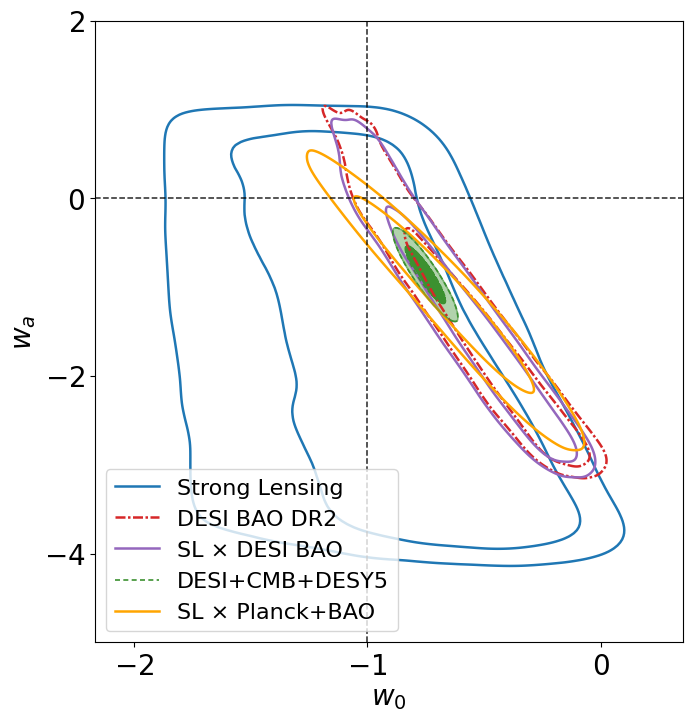

In [37]:
# === 代码块①：在原图基础上新增“SL × Planck+BAO”（橙色实线、不填充） ===
# pip install getdist matplotlib scipy
import os, glob
import numpy as np
import matplotlib.pyplot as plt
from getdist.mcsamples import MCSamples, loadMCSamples
from getdist import plots
from scipy.stats import gaussian_kde

# ====================== 基础路径（按需修改） ======================
base_dir       = "/home/astrodust/SG/sgl_cosmo/GLS_cosmo01"
local_pairs    = [("linear", "Tri")]      # 本地 3D 链（含 Ωm, w0, wa）
local_col_idx  = {'omegam': 0, 'w0': 1, 'wa': 2}
burnin_frac    = 0.30

# DESI BAO (w0–wa) 文本链目录（含 chain.*.txt）
desi_bao_folder = r"/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/DESI_BAO_base_w_wa/desi-bao-all"

# Planck+BAO (w0–wa) MCMC 根目录（CosmoMC/GetDist 样式）
planck_base_dir   = "/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data"
planck_base_label = "base_w_wa"
planck_root_bao = os.path.join(
    planck_base_dir, planck_base_label,
    "plikHM_TTTEEE_lowl_lowE_BAO",
    f"{planck_base_label}_plikHM_TTTEEE_lowl_lowE_BAO"
)

# DESI+CMB+DESY5 的二维高斯“摘要”（用于填充）
mu_desi     = (-0.752, -0.86)   # (w0, wa)
sigma_desi  = (0.057, 0.215)    # (σ_w0, σ_wa)
rho_desi    = -0.90

# ====================== 工具函数：加载/派生 ======================
def numpy3d_to_mcsamples_w0wa(arr, burnin_frac=0.3, col_idx=None, label=None):
    if arr.ndim == 3:
        nwalk, nstep, ndim = arr.shape
        start = int(burnin_frac * nstep)
        flat = arr[:, start:, :].reshape(-1, ndim)
    else:
        flat = arr
    i_w0 = col_idx['w0']; i_wa = col_idx['wa']
    sub  = flat[:, [i_w0, i_wa]]
    mcs = MCSamples(samples=sub, names=['w0','wa'], labels=[r'w_0', r'w_a'])
    if label: mcs.label = label
    return mcs

def auto_limits_multi(samples_list, name, q=(0.5, 99.5), pad=0.15):
    vals = []
    for s in samples_list:
        try:
            arr = getattr(s.getParams(), name)
            vals.append(np.percentile(arr, q))
        except Exception:
            pass
    if not vals:
        return None
    vals = np.array(vals)
    lo, hi = np.min(vals[:, 0]), np.max(vals[:, 1])
    w = hi - lo
    return lo - pad*w, hi + pad*w

def _extract_2d_from_mcs(mcs, xname='w0', yname='wa'):
    P = mcs.getParams()
    x = getattr(P, xname)
    y = getattr(P, yname)
    return np.vstack([x, y]).T

def make_joint_by_kde(base_mcs, ref_pts, label, bw='scott'):
    """
    用 ref_pts(N,2) 的 KDE 在 base_mcs 的 (w0, wa) 点上评估密度，作为附加权重 → 联合后验。
    假设两者对 (w0, wa) 的先验一致或近似均匀；若不同需在此做先验校正。
    """
    base_pts = _extract_2d_from_mcs(base_mcs, 'w0', 'wa')
    w_base   = base_mcs.weights if base_mcs.weights is not None else np.ones(base_pts.shape[0])
    kde  = gaussian_kde(ref_pts.T, bw_method=bw)
    dens = np.clip(kde(base_pts.T), 1e-300, None)
    w_joint = w_base * dens
    joint = MCSamples(samples=base_pts, names=['w0','wa'], labels=[r'w_0', r'w_a'], weights=w_joint)
    joint.label = label
    return joint

def _getcol(a, *candidates):
    for name in candidates:
        if name in a.dtype.names:
            return a[name]
    return None

def load_desi_bao_w0wa(folder, label=r"DESI BAO (w0–wa)"):
    """读取 DESI BAO (w0–wa) 文本链（chain.*.txt），返回仅含 (w0, wa) 的 MCSamples。"""
    files  = sorted(glob.glob(os.path.join(folder, "chain.*.txt")))
    if not files:
        raise FileNotFoundError("No chain.*.txt found under " + folder)
    parts = [np.genfromtxt(f, names=True, comments="#") for f in files]
    data  = np.concatenate(parts)
    w0 = _getcol(data, "w0", "w", "w_0")
    wa = _getcol(data, "wa", "w_a", "wprime", "w_a_cpl")
    if w0 is None or wa is None:
        raise KeyError("DESI: need columns 'w0' and 'wa'（兼容别名：w / w_0, w_a / wprime / w_a_cpl）.")
    weights = _getcol(data, "weight", "weights", "Weight", "Weights")
    samples = np.vstack([w0, wa]).T
    gd = MCSamples(samples=samples, names=["w0","wa"], labels=[r"w_0", r"w_a"],
                   weights=weights if weights is not None else None)
    gd.updateSettings({'ignore_rows': 0.0})
    gd.label = label
    return gd

def gaussian_to_mcsamples_w0wa(mu, sigmas, rho, nsamp=200000, seed=42, label="DESI+CMB+DESY5"):
    """将 (mu, sigmas, rho) 的二维高斯近似采样为 MCSamples，便于绘图与统计。"""
    rng = np.random.default_rng(seed)
    s0, sa = sigmas
    cov = np.array([[s0**2, rho*s0*sa],
                    [rho*s0*sa, sa**2]], dtype=float)
    samples = rng.multivariate_normal(mean=mu, cov=cov, size=nsamp)
    mcs = MCSamples(samples=samples, names=['w0','wa'], labels=[r'w_0', r'w_a'])
    mcs.updateSettings({'ignore_rows':0.0})
    mcs.label = label
    return mcs

def ensure_w0_wa(samples):
    """Planck 链若字段名不同，统一为 w0/wa。"""
    P = samples.getParams()
    names = {p.name for p in samples.getParamNames().names}
    if 'w0' not in names:
        if hasattr(P, 'w'):
            samples.addDerived(P.w, name='w0', label=r'w_0')
        else:
            raise RuntimeError("Planck 链未包含 w0/w。")
    if 'wa' not in names:
        if hasattr(P, 'wa'):
            pass
        else:
            raise RuntimeError("Planck 链未包含 wa。")
    try: samples.setLabel('w0', r'w_0')
    except: pass
    try: samples.setLabel('wa', r'w_a')
    except: pass
    return samples

# ====================== 加载数据 ======================
# 本地 SL（含 w0, wa）
local_mcs = []
for evo, prior in local_pairs:
    f = os.path.join(base_dir, "Output", f"{evo}-{prior}", f"mcmc_cosmop3D-{evo}-{prior}.npy")
    if not os.path.isfile(f):
        raise FileNotFoundError(f"找不到本地链文件: {f}")
    arr = np.load(f)
    mcs = numpy3d_to_mcsamples_w0wa(arr, burnin_frac=burnin_frac, col_idx=local_col_idx,
                                    label=r"Strong Lensing")
    local_mcs.append(mcs)
SL = local_mcs[0]

# DESI BAO（w0–wa）
BAO = load_desi_bao_w0wa(desi_bao_folder, label=r"DESI BAO DR2")

# Planck+BAO（w0–wa）
planck_bao = loadMCSamples(planck_root_bao, settings={'ignore_rows': 0.3}, no_cache=True)
planck_bao = ensure_w0_wa(planck_bao)
planck_bao.label = r"Planck+BAO"

# DESI+CMB+DESY5 高斯近似 → 样本（此组需要填充）
DESI_CMB_DESY5 = gaussian_to_mcsamples_w0wa(mu_desi, sigma_desi, rho_desi,
                                            nsamp=200000, seed=123, label=r"DESI+CMB+DESY5")

# ====================== 联合限制（KDE 重加权） ======================
SL_pts = _extract_2d_from_mcs(SL, 'w0', 'wa')

# SL + BAO
SLxBAO = make_joint_by_kde(
    base_mcs=BAO,
    ref_pts=SL_pts,
    label=r"SL × DESI BAO",
    bw='scott'
)

# SL + Planck+BAO  ← 新增
SLxPlanckBAO = make_joint_by_kde(
    base_mcs=planck_bao,
    ref_pts=SL_pts,
    label=r"SL × Planck+BAO",
    bw='scott'
)

# ====================== 画 w0–wa：五组 ======================
to_plot = [SL, BAO, SLxBAO, DESI_CMB_DESY5, SLxPlanckBAO]
legend_labels = [s.label for s in to_plot]

# 颜色与线型：
COL_SL        = '#1f77b4'   # 蓝（实线）
COL_BAO       = '#d62728'   # 红（-.）
COL_SLBAO     = '#9467bd'   # 紫（实线）
COL_DESIC     = '#3c9130'   # 绿（填充用）
COL_SLPB      = 'orange'    # 橙（实线，不填充） ← 新增

colors    = [COL_SL,  COL_BAO,  COL_SLBAO, COL_DESIC, COL_SLPB]
line_args = [
    {'ls': '-',  'lw': 1.8},   # SL
    {'ls': '-.', 'lw': 1.8},   # BAO
    {'ls': '-',  'lw': 1.8},   # SL×BAO
    {'ls': '--', 'lw': 1.2},   # DESI+CMB+DESY5（轮廓占位）
    {'ls': '-',  'lw': 1.8},   # SL×Planck+BAO  ← 新增（橙色实线）
]

g = plots.get_subplot_plotter(width_inch=7.2)
g.settings.num_plot_contours = 2
g.settings.axes_fontsize = 20
g.settings.legend_fontsize = 16

# 先画全部不填充的轮廓（DESI 仅占位）
g.plot_2d(
    to_plot,
    ['w0', 'wa'],
    filled=False,
    colors=colors,
    line_args=line_args,
    legend_labels=None,
)

# 仅对 DESI+CMB+DESY5 填充
g.plot_2d(DESI_CMB_DESY5, ['w0', 'wa'], filled=True,
          colors=[COL_DESIC], add_legend_proxy=False, alpha=0.30)

ax = g.subplots[0, 0]
xlim = auto_limits_multi(to_plot, 'w0') or (-1.4, -0.5)
ylim = (-5.0, 2.0)
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r'$w_0$', fontsize=20)
ax.set_ylabel(r'$w_a$', fontsize=20)

# 参考虚线
ax.axvline(-1.0, ls='--', lw=1.1, color='k', alpha=0.85)
ax.axhline(0.0,  ls='--', lw=1.1, color='k', alpha=0.85)

g.add_legend(legend_labels, legend_loc='lower left', colored_text=False)

out = "w0wacdm_w0_wa_SL_bao.png"
g.export(out)
print(f"Saved plot: {out}")


In [36]:
# === 1D summaries for (omegam, w0, wa) with robust aliasing and missing-field handling ===
import numpy as np
from scipy.stats import gaussian_kde

# ---------- weighted helpers ----------
def _normalize_weights(w):
    if w is None: return None
    w = np.asarray(w, float)
    s = np.sum(w)
    if s <= 0 or not np.isfinite(s): return None
    return w / s

def _weighted_quantile(x, q, w=None):
    x = np.asarray(x, float)
    if w is None:
        return np.quantile(x, q)
    w = np.asarray(w, float)
    s = np.argsort(x)
    xs, ws = x[s], w[s]
    cdf = np.cumsum(ws) / np.sum(ws)
    return np.interp(q, cdf, xs)

def _weighted_quantiles(x, qs, w=None):
    qs = np.atleast_1d(qs).astype(float)
    return np.array([_weighted_quantile(x, q, w) for q in qs])

def _weighted_median(x, w=None):
    return _weighted_quantile(x, 0.5, w)

def _weighted_mad(x, w=None, scale=1.4826):
    med = _weighted_median(x, w)
    return scale * _weighted_median(np.abs(x - med), w)

def _oned_peak(x, w=None, grids=2048):
    x = np.asarray(x, float)
    # guard: if degenerate
    xmin, xmax = np.min(x), np.max(x)
    if not np.isfinite(xmin) or not np.isfinite(xmax) or xmin == xmax:
        return float(np.median(x))
    grid = np.linspace(xmin, xmax, grids)
    kde  = gaussian_kde(x, weights=_normalize_weights(w)) if w is not None else gaussian_kde(x)
    dens = kde(grid)
    return float(grid[np.argmax(dens)])

def _weighted_mean_sigma(x, w=None):
    x = np.asarray(x, float)
    if w is None:
        return float(np.mean(x)), float(np.std(x, ddof=0))
    wn = _normalize_weights(w)
    mu = float(np.sum(wn * x))
    sig = float(np.sqrt(np.sum(wn * (x - mu)**2)))
    return mu, sig

# ---------- read parameter array with aliases ----------
_ALIAS = {
    'omegam': ['omegam','om','Omega_m','OmegaM','omm'],
    'w0'    : ['w0','w','w_0'],
    'wa'    : ['wa','w_a','wprime','w_a_cpl']
}

def _get_param_array_with_alias(mcs, target):
    names = [p.name for p in mcs.getParamNames().names]
    # fast path exact
    if target in names:
        P = mcs.getParams()
        return np.asarray(getattr(P, target), float)
    # try aliases
    for alt in _ALIAS.get(target, []):
        if alt in names:
            P = mcs.getParams()
            return np.asarray(getattr(P, alt), float)
    # sometimes GetDist stores as attributes but not in names; try getattr chain
    P = mcs.getParams()
    for alt in _ALIAS.get(target, []):
        if hasattr(P, alt):
            return np.asarray(getattr(P, alt), float)
    # not found
    return None

# ---------- summarize & print ----------
def summarize_mcs_1dset(mcs, names=('omegam','w0','wa')):
    out = {}
    wts = None if mcs.weights is None else np.asarray(mcs.weights, float)
    for nm in names:
        arr = _get_param_array_with_alias(mcs, nm)
        if arr is None:
            out[nm] = None  # mark missing
            continue
        mean, sigma = _weighted_mean_sigma(arr, wts)
        med  = _weighted_median(arr, wts)
        mad  = _weighted_mad(arr, wts)
        pk   = _oned_peak(arr, wts)
        q16, q84 = _weighted_quantiles(arr, [0.16, 0.84], wts)
        out[nm] = dict(
            mean=mean, sigma=sigma,
            median=med, mad=mad,
            peak=pk, q16=q16, q84=q84,
            dmed_minus=med-q16, dmed_plus=q84-med
        )
    return out

def print_summary_1d(tag, summ, names=('omegam','w0','wa')):
    print(f"\n=== {tag} ===")
    for nm in names:
        s = summ.get(nm, None)
        if s is None:
            print(f"{nm:7s}: (N/A)")
            continue
        peak_txt   = f"peak = {s['peak']:.6f}"
        median_txt = (f"median = {s['median']:.6f} "
                      f"(q16={s['q16']:.6f}, q84={s['q84']:.6f}; "
                      f"Δ-={s['dmed_minus']:.6f}, Δ+={s['dmed_plus']:.6f}) "
                      f"(MAD={s['mad']:.6f})")
        mean_txt   = f"mean = {s['mean']:.6f}, sigma = {s['sigma']:.6f}"
        print(f"{nm:7s}: {peak_txt} | {median_txt} | {mean_txt}")

# ---------- run on your datasets ----------
stats_targets = [
    (SL.label,            SL),
    (BAO.label,           BAO),
    (planck_bao.label,    planck_bao),
    (SLxBAO.label,        SLxBAO),
    (SLxPlanckBAO.label,  SLxPlanckBAO),
]

for tag, mcs in stats_targets:
    s = summarize_mcs_1dset(mcs, names=('omegam','w0','wa'))
    print_summary_1d(tag, s, names=('omegam','w0','wa'))



=== Strong Lensing ===
omegam : (N/A)
w0     : peak = -0.905031 | median = -0.940721 (q16=-1.443451, q84=-0.494801; Δ-=0.502730, Δ+=0.445920) (MAD=0.478171) | mean = -0.957948, sigma = 0.444868
wa     : peak = -3.525898 | median = -1.963675 (q16=-3.399313, q84=-0.109082; Δ-=1.435637, Δ+=1.854593) (MAD=1.749455) | mean = -1.806156, sigma = 1.415610

=== DESI BAO DR2 ===
omegam : (N/A)
w0     : peak = -0.275285 | median = -0.440097 (q16=-0.775316, q84=-0.206943; Δ-=0.335219, Δ+=0.233155) (MAD=0.280765) | mean = -0.479873, sigma = 0.268407
wa     : peak = -2.761688 | median = -1.840726 (q16=-2.643038, q84=-0.614079; Δ-=0.802311, Δ+=1.226647) (MAD=0.989272) | mean = -1.655958, sigma = 0.967060

=== Planck+BAO ===
omegam : peak = 0.339102 | median = 0.341583 (q16=0.316073, q84=0.367529; Δ-=0.025510, Δ+=0.025946) (MAD=0.025958) | mean = 0.341667, sigma = 0.025433
w0     : peak = -0.558300 | median = -0.572602 (q16=-0.850358, q84=-0.301379; Δ-=0.277756, Δ+=0.271223) (MAD=0.279101) | mean = -

In [20]:
# === 代码块②：读取原始链以获得 Ωm，并输出 SL / BAO / SL×BAO 的一维统计 ===
# 与画图分离，可单独运行
import os, glob
import numpy as np
from scipy.stats import gaussian_kde

# ---------- 路径与本地链配置（与画图保持一致） ----------
base_dir       = "/home/astrodust/SG/sgl_cosmo/GLS_cosmo01"
local_pairs    = [("linear", "0.22")]   # 本地 3D 链（含 Ωm,w0,wa）
local_col_idx  = {'omegam': 0, 'w0': 1, 'wa': 2}
burnin_frac    = 0.30

desi_bao_folder = r"/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/DESI_BAO_base_w_wa/desi-bao-all"

# ---------- 读取：本地 SL 链（从 numpy 三维阵列里取出 Ωm,w0,wa） ----------
def load_local_SL_arrays(base_dir, evo, prior, col_idx, burnin_frac=0.3):
    f = os.path.join(base_dir, "Output", f"{evo}-{prior}", f"mcmc_cosmop3D-{evo}-{prior}.npy")
    if not os.path.isfile(f):
        raise FileNotFoundError(f"找不到本地链文件: {f}")
    arr = np.load(f)  # (nwalkers, nsteps, ndim)
    if arr.ndim != 3:
        flat = arr
    else:
        nwalk, nstep, ndim = arr.shape
        start = int(burnin_frac * nstep)
        flat = arr[:, start:, :].reshape(-1, arr.shape[-1])
    omegam = flat[:, col_idx['omegam']]
    w0     = flat[:, col_idx['w0']]
    wa     = flat[:, col_idx['wa']]
    return omegam, w0, wa

# ---------- 读取：DESI BAO (w0–wa) 文本链（尽力获得/派生 Ωm） ----------
def _getcol(a, *candidates):
    for name in candidates:
        if name in a.dtype.names:
            return a[name]
    return None

def load_desi_bao_w0wa_with_omegam(folder):
    files  = sorted(glob.glob(os.path.join(folder, "chain.*.txt")))
    if not files:
        raise FileNotFoundError("No chain.*.txt found under " + folder)
    parts = [np.genfromtxt(f, names=True, comments="#") for f in files]
    data  = np.concatenate(parts)

    # w0, wa
    w0 = _getcol(data, "w0", "w", "w_0")
    wa = _getcol(data, "wa", "w_a", "wprime", "w_a_cpl")
    if w0 is None or wa is None:
        raise KeyError("DESI: 需要 'w0' 和 'wa'（也兼容 w / w_0, w_a / wprime / w_a_cpl）")

    # Ωm：直接取列，或由物理密度派生
    omegam = _getcol(data, "omegam", "omm", "Omega_m", "OmegaM", "Om")
    if omegam is None:
        obh2 = _getcol(data, "ombh2", "omega_b", "Omega_b_h2", "Obh2")
        och2 = _getcol(data, "omch2", "omega_cdm", "Omega_c_h2", "Och2")
        h    = _getcol(data, "h")
        if h is None:
            H0 = _getcol(data, "H0")
            if H0 is None:
                raise KeyError("DESI: 派生 Ωm 需要 'h' 或 'H0'")
            h = H0/100.0
        if (obh2 is None) or (och2 is None):
            raise KeyError("DESI: 派生 Ωm 需要 'ombh2' 与 'omch2'")
        omegam = (obh2 + och2) / (h**2)

    weights = _getcol(data, "weight", "weights", "Weight", "Weights")
    return np.asarray(omegam, float), np.asarray(w0, float), np.asarray(wa, float), (None if weights is None else np.asarray(weights, float))

# ---------- 统计工具（带权） ----------
def _normalize_weights(w):
    if w is None: return None
    w = np.asarray(w, float); s = np.sum(w)
    if s <= 0 or not np.isfinite(s): return None
    return w / s

def _weighted_quantile(x, q, w=None):
    x = np.asarray(x, float)
    if w is None: return np.quantile(x, q)
    w = np.asarray(w, float); s = np.argsort(x)
    xs, ws = x[s], w[s]
    cdf = np.cumsum(ws) / np.sum(ws)
    return np.interp(q, cdf, xs)

def _weighted_quantiles(x, qs, w=None):
    qs = np.atleast_1d(qs).astype(float)
    return np.array([_weighted_quantile(x, q, w) for q in qs])

def _weighted_median(x, w=None):
    return _weighted_quantile(x, 0.5, w)

def _weighted_mad(x, w=None, scale=1.4826):
    med = _weighted_median(x, w)
    return scale * _weighted_median(np.abs(x - med), w)

def _oned_peak(x, w=None, grids=2048):
    x = np.asarray(x, float)
    grid = np.linspace(np.min(x), np.max(x), grids)
    kde  = gaussian_kde(x, weights=w) if w is not None else gaussian_kde(x)
    dens = kde(grid)
    return grid[np.argmax(dens)]

def _weighted_mean_sigma(x, w=None):
    x = np.asarray(x, float)
    if w is None:
        return np.mean(x), np.std(x, ddof=0)
    wn = _normalize_weights(w); mu = np.sum(wn * x)
    sig = np.sqrt(np.sum(wn * (x - mu)**2))
    return mu, sig

def summarize_1d(x, w=None):
    mean, sigma = _weighted_mean_sigma(x, w)
    med  = _weighted_median(x, w)
    mad  = _weighted_mad(x, w)
    pk   = _oned_peak(x, w)
    q16, q84 = _weighted_quantiles(x, [0.16, 0.84], w)
    return dict(
        mean=mean, sigma=sigma,
        median=med, mad=mad,
        peak=pk, q16=q16, q84=q84,
        dmed_minus=med-q16, dmed_plus=q84-med
    )

def print_summary_block(tag, s):
    print(f"\n=== {tag} ===")
    print(f"omegam: peak = {s['peak']:.6f} | "
          f"median = {s['median']:.6f} (q16={s['q16']:.6f}, q84={s['q84']:.6f}; Δ-={s['dmed_minus']:.6f}, Δ+={s['dmed_plus']:.6f}) (MAD={s['mad']:.6f}) | "
          f"mean = {s['mean']:.6f}, sigma = {s['sigma']:.6f}")

# ---------- 实际计算 ----------
# 1) SL（本地链）
SL_omegam, SL_w0, SL_wa = load_local_SL_arrays(base_dir, *local_pairs[0], col_idx=local_col_idx, burnin_frac=burnin_frac)

# 2) BAO（DESI 文本链：w0, wa, omegam, weight）
BAO_omegam, BAO_w0, BAO_wa, BAO_w = load_desi_bao_w0wa_with_omegam(desi_bao_folder)

# 3) 用 SL 的 (w0,wa) 做 KDE，在 BAO 的 (w0,wa) 上评估 → 得到联合权重（与画图一致）
kde_SL = gaussian_kde(np.vstack([SL_w0, SL_wa]))   # SL 一般无权重
dens   = kde_SL(np.vstack([BAO_w0, BAO_wa]))
dens   = np.clip(dens, 1e-300, None)
w_joint = (BAO_w if BAO_w is not None else np.ones_like(BAO_omegam)) * dens

# ---------- 输出一维统计（只对这 3 个 target；不包含 DESI_CMB_DESY5） ----------
S_SL         = summarize_1d(SL_omegam, w=None)
S_BAO        = summarize_1d(BAO_omegam, w=BAO_w)
S_SLxBAO     = summarize_1d(BAO_omegam, w=w_joint)

print_summary_block("SL", S_SL)
print_summary_block("BAO", S_BAO)
print_summary_block("SL × BAO (KDE 重加权)", S_SLxBAO)



=== SL ===
omegam: peak = 0.249402 | median = 0.239647 (q16=0.167363, q84=0.313538; Δ-=0.072284, Δ+=0.073891) (MAD=0.072661) | mean = 0.240231, sigma = 0.075263

=== BAO ===
omegam: peak = 0.371248 | median = 0.358614 (q16=0.318464, q84=0.384235; Δ-=0.040151, Δ+=0.025621) (MAD=0.031270) | mean = 0.351927, sigma = 0.034916

=== SL × BAO (KDE 重加权) ===
omegam: peak = 0.363801 | median = 0.349242 (q16=0.311137, q84=0.376776; Δ-=0.038105, Δ+=0.027534) (MAD=0.032845) | mean = 0.344293, sigma = 0.033543


Removed no burn in
Removed no burn in
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_2.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_3.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_1.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_4.txt
Removed no burn in
Removed no burn in
Removed no burn in
Saved plot: omegam_w0_SL_and_joint.png


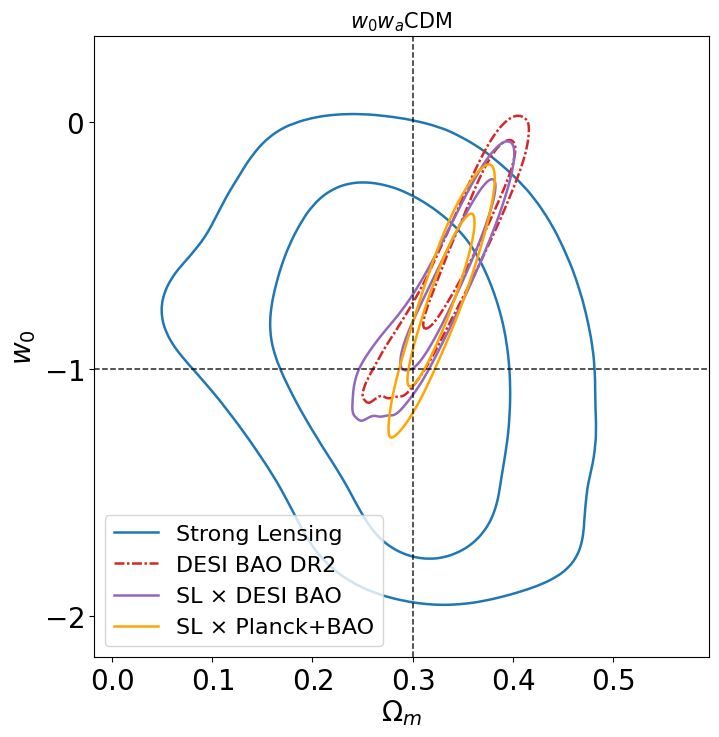

In [33]:
# pip install getdist matplotlib scipy
import os, glob
import numpy as np
import matplotlib.pyplot as plt
from getdist.mcsamples import MCSamples, loadMCSamples
from getdist import plots
from scipy.stats import gaussian_kde

# ====================== 基础路径（按需修改） ======================
base_dir       = "/home/astrodust/SG/sgl_cosmo/GLS_cosmo01"
local_pairs    = [("linear", "Tri")]   # 本地 3D 链（含 omegam, w0, wa）
local_col_idx  = {'omegam': 0, 'w0': 1, 'wa': 2}
burnin_frac    = 0.30

# DESI BAO (常见文本链，含 omegam / w0)
desi_bao_folder = r"/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/DESI_BAO_base_w_wa/desi-bao-all"

# Planck+BAO（CosmoMC/GetDist 样式根路径）
planck_base_dir   = "/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data"
planck_base_label = "base_w_wa"
planck_root_bao = os.path.join(
    planck_base_dir, planck_base_label,
    "plikHM_TTTEEE_lowl_lowE_BAO",
    f"{planck_base_label}_plikHM_TTTEEE_lowl_lowE_BAO"
)

# ====================== 工具函数 ======================
def numpy3d_to_mcsamples_Om_w0(arr, burnin_frac=0.3, col_idx=None, label=None):
    """
    从本地 (nwalk, nstep, ndim) 或 (N, ndim) 的数组取出 (omegam, w0) 两列为 MCSamples。
    """
    if arr.ndim == 3:
        nwalk, nstep, ndim = arr.shape
        start = int(burnin_frac * nstep)
        flat = arr[:, start:, :].reshape(-1, ndim)
    else:
        flat = arr
    i_om = col_idx['omegam']; i_w0 = col_idx['w0']
    sub  = flat[:, [i_om, i_w0]]
    mcs = MCSamples(samples=sub, names=['omegam','w0'], labels=[r'\Omega_m', r'w_0'])
    if label: mcs.label = label
    return mcs

def _getcol(a, *candidates):
    for name in candidates:
        if name in a.dtype.names:
            return a[name]
    return None

def load_desi_bao_Om_w0(folder, label=r"DESI BAO DR2"):
    """
    读取 DESI BAO 文本链（chain.*.txt），抽取 (omegam, w0)。
    尝试兼容列名别名：omegam/omm/om、w0/w/w_0。
    """
    files = sorted(glob.glob(os.path.join(folder, "chain.*.txt")))
    if not files:
        raise FileNotFoundError("No chain.*.txt found under " + folder)
    parts = [np.genfromtxt(f, names=True, comments="#") for f in files]
    data  = np.concatenate(parts)

    Om  = _getcol(data, 'omegam', 'omm', 'om', 'Omega_m', 'OmegaM')
    w0  = _getcol(data, 'w0', 'w', 'w_0')

    if Om is None or w0 is None:
        raise KeyError("DESI: 需要列 omegam 与 w0（兼容别名：omm/om, w/w_0）。")

    weights = _getcol(data, 'weight','weights','Weight','Weights')
    samples = np.vstack([Om, w0]).T
    gd = MCSamples(samples=samples, names=['omegam','w0'],
                   labels=[r'\Omega_m', r'w_0'],
                   weights=weights if weights is not None else None)
    gd.updateSettings({'ignore_rows': 0.0})
    gd.label = label
    return gd

def ensure_Om_w0(samples):
    """
    Planck 链若字段名不同，统一提供 omegam / w0。
    """
    P = samples.getParams()
    names = {p.name for p in samples.getParamNames().names}
    # Omega_m
    if 'omegam' not in names:
        # 常见名称兼容
        cand = None
        for nm in ['omegam','om','Omega_m','OmegaM','omm']:
            if hasattr(P, nm):
                cand = getattr(P, nm); break
        if cand is None:
            raise RuntimeError("Planck 链中未找到 Ωm（omegam/om/Omega_m 等）。")
        samples.addDerived(cand, name='omegam', label=r'\Omega_m')
    else:
        try: samples.setLabel('omegam', r'\Omega_m')
        except: pass

    # w0
    if 'w0' not in names:
        if hasattr(P, 'w'):
            samples.addDerived(P.w, name='w0', label=r'w_0')
        elif hasattr(P, 'w0'):
            try: samples.setLabel('w0', r'w_0')
            except: pass
        else:
            raise RuntimeError("Planck 链未包含 w0/w。")
    else:
        try: samples.setLabel('w0', r'w_0')
        except: pass
    return samples

def _extract_2d_from_mcs(mcs, xname='omegam', yname='w0'):
    P = mcs.getParams()
    x = getattr(P, xname)
    y = getattr(P, yname)
    return np.vstack([x, y]).T

def make_joint_by_kde_2d(base_mcs, ref_pts, names=('omegam','w0'), label="Joint", bw='scott'):
    """
    用 ref_pts(N,2) 对 base_mcs 的 (x,y) 做 KDE 评估 → 作为权重得到联合后验。
    假设两者对 (x,y) 先验一致或近似均匀；如不一致需在此处做先验校正。
    """
    xname, yname = names
    base_xy = _extract_2d_from_mcs(base_mcs, xname, yname)
    w_base  = base_mcs.weights if base_mcs.weights is not None else np.ones(base_xy.shape[0])

    kde  = gaussian_kde(ref_pts.T, bw_method=bw)
    dens = np.clip(kde(base_xy.T), 1e-300, None)
    w_joint = w_base * dens

    joint = MCSamples(samples=base_xy, names=[xname, yname],
                      labels=[r'\Omega_m', r'w_0'], weights=w_joint)
    joint.label = label
    return joint

def auto_limits_multi(samples_list, name, q=(0.5, 99.5), pad=0.15):
    vals = []
    for s in samples_list:
        try:
            arr = getattr(s.getParams(), name)
            vals.append(np.percentile(arr, q))
        except Exception:
            pass
    if not vals:
        return None
    vals = np.array(vals)
    lo, hi = np.min(vals[:, 0]), np.max(vals[:, 1])
    w = hi - lo
    return lo - pad*w, hi + pad*w

# ====================== 加载数据 ======================
# 本地 SL（含 omegam, w0, wa）
local_mcs = []
for evo, prior in local_pairs:
    f = os.path.join(base_dir, "Output", f"{evo}-{prior}", f"mcmc_cosmop3D-{evo}-{prior}.npy")
    if not os.path.isfile(f):
        raise FileNotFoundError(f"找不到本地链文件: {f}")
    arr = np.load(f)
    mcs = numpy3d_to_mcsamples_Om_w0(arr, burnin_frac=burnin_frac, col_idx=local_col_idx,
                                     label=r"Strong Lensing")
    local_mcs.append(mcs)
SL = local_mcs[0]

# DESI BAO（Ωm–w0）
BAO = load_desi_bao_Om_w0(desi_bao_folder, label=r"DESI BAO DR2")

# Planck+BAO（Ωm–w0）
planck_bao = loadMCSamples(planck_root_bao, settings={'ignore_rows': 0.3}, no_cache=True)
planck_bao = ensure_Om_w0(planck_bao)
planck_bao.label = r"Planck+BAO"

# ====================== 联合限制（KDE 重加权） ======================
# 注意：我们用“对方”为 base，把对方在 (Ωm,w0) 的后验点按 SL 的 KDE 作为权重 → 相当于 SL × 对方
SL_pts = _extract_2d_from_mcs(SL, 'omegam', 'w0')

SLxBAO = make_joint_by_kde_2d(
    base_mcs=BAO,
    ref_pts=SL_pts,
    names=('omegam','w0'),
    label=r"SL × DESI BAO",
    bw='scott'
)

SLxPlanckBAO = make_joint_by_kde_2d(
    base_mcs=planck_bao,
    ref_pts=SL_pts,
    names=('omegam','w0'),
    label=r"SL × Planck+BAO",
    bw='scott'
)

# ====================== 绘图（Ωm–w0） ======================
to_plot = [SL, BAO, SLxBAO, SLxPlanckBAO]
legend_labels = [s.label for s in to_plot]

# 样式：SL(蓝实) / BAO(红-. ) / SL×BAO(紫实) / SL×Planck+BAO(橙实)
COL_SL   = '#1f77b4'
COL_BAO  = '#d62728'
COL_SLBAO= '#9467bd'
COL_SLPB = 'orange'

colors    = [COL_SL, COL_BAO, COL_SLBAO, COL_SLPB]
line_args = [
    {'ls': '-',  'lw': 1.8},   # SL
    {'ls': '-.', 'lw': 1.8},   # BAO
    {'ls': '-',  'lw': 1.8},   # SL×BAO
    {'ls': '-',  'lw': 1.8},   # SL×Planck+BAO
]

g = plots.get_subplot_plotter(width_inch=7.2)
g.settings.num_plot_contours = 2
g.settings.axes_fontsize = 20
g.settings.legend_fontsize = 16

# 画全部不填充的轮廓
g.plot_2d(
    to_plot,
    ['omegam', 'w0'],  # x: Ωm, y: w0
    filled=False,
    colors=colors,
    line_args=line_args,
    legend_labels=None,
)

ax = g.subplots[0, 0]
xlim = auto_limits_multi(to_plot, 'omegam') or (0.15, 0.45)
ylim = auto_limits_multi(to_plot, 'w0')     or (-1.6, -0.6)
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r'$\Omega_m$', fontsize=20)
ax.set_ylabel(r'$w_0$', fontsize=20)
ax.set_title(r'$w_0 w_a$CDM',fontsize=15)

# 参考线：ΛCDM (w0=-1)
ax.axhline(-1.0, ls='--', lw=1.1, color='k', alpha=0.85)
ax.axvline(0.3,  ls='--', lw=1.1, color='k', alpha=0.85)

g.add_legend(legend_labels, legend_loc='lower left', colored_text=False)

out = "omegam_w0_SL_and_joint.png"
g.export(out)
print(f"Saved plot: {out}")


In [34]:
# === 1D summaries for (omegam, w0, wa) with robust aliasing and missing-field handling ===
import numpy as np
from scipy.stats import gaussian_kde

# ---------- weighted helpers ----------
def _normalize_weights(w):
    if w is None: return None
    w = np.asarray(w, float)
    s = np.sum(w)
    if s <= 0 or not np.isfinite(s): return None
    return w / s

def _weighted_quantile(x, q, w=None):
    x = np.asarray(x, float)
    if w is None:
        return np.quantile(x, q)
    w = np.asarray(w, float)
    s = np.argsort(x)
    xs, ws = x[s], w[s]
    cdf = np.cumsum(ws) / np.sum(ws)
    return np.interp(q, cdf, xs)

def _weighted_quantiles(x, qs, w=None):
    qs = np.atleast_1d(qs).astype(float)
    return np.array([_weighted_quantile(x, q, w) for q in qs])

def _weighted_median(x, w=None):
    return _weighted_quantile(x, 0.5, w)

def _weighted_mad(x, w=None, scale=1.4826):
    med = _weighted_median(x, w)
    return scale * _weighted_median(np.abs(x - med), w)

def _oned_peak(x, w=None, grids=2048):
    x = np.asarray(x, float)
    # guard: if degenerate
    xmin, xmax = np.min(x), np.max(x)
    if not np.isfinite(xmin) or not np.isfinite(xmax) or xmin == xmax:
        return float(np.median(x))
    grid = np.linspace(xmin, xmax, grids)
    kde  = gaussian_kde(x, weights=_normalize_weights(w)) if w is not None else gaussian_kde(x)
    dens = kde(grid)
    return float(grid[np.argmax(dens)])

def _weighted_mean_sigma(x, w=None):
    x = np.asarray(x, float)
    if w is None:
        return float(np.mean(x)), float(np.std(x, ddof=0))
    wn = _normalize_weights(w)
    mu = float(np.sum(wn * x))
    sig = float(np.sqrt(np.sum(wn * (x - mu)**2)))
    return mu, sig

# ---------- read parameter array with aliases ----------
_ALIAS = {
    'omegam': ['omegam','om','Omega_m','OmegaM','omm'],
    'w0'    : ['w0','w','w_0'],
    'wa'    : ['wa','w_a','wprime','w_a_cpl']
}

def _get_param_array_with_alias(mcs, target):
    names = [p.name for p in mcs.getParamNames().names]
    # fast path exact
    if target in names:
        P = mcs.getParams()
        return np.asarray(getattr(P, target), float)
    # try aliases
    for alt in _ALIAS.get(target, []):
        if alt in names:
            P = mcs.getParams()
            return np.asarray(getattr(P, alt), float)
    # sometimes GetDist stores as attributes but not in names; try getattr chain
    P = mcs.getParams()
    for alt in _ALIAS.get(target, []):
        if hasattr(P, alt):
            return np.asarray(getattr(P, alt), float)
    # not found
    return None

# ---------- summarize & print ----------
def summarize_mcs_1dset(mcs, names=('omegam','w0','wa')):
    out = {}
    wts = None if mcs.weights is None else np.asarray(mcs.weights, float)
    for nm in names:
        arr = _get_param_array_with_alias(mcs, nm)
        if arr is None:
            out[nm] = None  # mark missing
            continue
        mean, sigma = _weighted_mean_sigma(arr, wts)
        med  = _weighted_median(arr, wts)
        mad  = _weighted_mad(arr, wts)
        pk   = _oned_peak(arr, wts)
        q16, q84 = _weighted_quantiles(arr, [0.16, 0.84], wts)
        out[nm] = dict(
            mean=mean, sigma=sigma,
            median=med, mad=mad,
            peak=pk, q16=q16, q84=q84,
            dmed_minus=med-q16, dmed_plus=q84-med
        )
    return out

def print_summary_1d(tag, summ, names=('omegam','w0','wa')):
    print(f"\n=== {tag} ===")
    for nm in names:
        s = summ.get(nm, None)
        if s is None:
            print(f"{nm:7s}: (N/A)")
            continue
        peak_txt   = f"peak = {s['peak']:.6f}"
        median_txt = (f"median = {s['median']:.6f} "
                      f"(q16={s['q16']:.6f}, q84={s['q84']:.6f}; "
                      f"Δ-={s['dmed_minus']:.6f}, Δ+={s['dmed_plus']:.6f}) "
                      f"(MAD={s['mad']:.6f})")
        mean_txt   = f"mean = {s['mean']:.6f}, sigma = {s['sigma']:.6f}"
        print(f"{nm:7s}: {peak_txt} | {median_txt} | {mean_txt}")

# ---------- run on your datasets ----------
stats_targets = [
    (SL.label,            SL),
    (BAO.label,           BAO),
    (planck_bao.label,    planck_bao),
    (SLxBAO.label,        SLxBAO),
    (SLxPlanckBAO.label,  SLxPlanckBAO),
]

for tag, mcs in stats_targets:
    s = summarize_mcs_1dset(mcs, names=('omegam','w0','wa'))
    print_summary_1d(tag, s, names=('omegam','w0','wa'))



=== Strong Lensing ===
omegam : peak = 0.279933 | median = 0.286130 (q16=0.204582, q84=0.370107; Δ-=0.081548, Δ+=0.083977) (MAD=0.083228) | mean = 0.286626, sigma = 0.086174
w0     : peak = -0.905031 | median = -0.940721 (q16=-1.443451, q84=-0.494801; Δ-=0.502730, Δ+=0.445920) (MAD=0.478171) | mean = -0.957948, sigma = 0.444868
wa     : (N/A)

=== DESI BAO DR2 ===
omegam : peak = 0.371248 | median = 0.358614 (q16=0.318464, q84=0.384235; Δ-=0.040151, Δ+=0.025621) (MAD=0.031270) | mean = 0.351927, sigma = 0.034916
w0     : peak = -0.275285 | median = -0.440097 (q16=-0.775316, q84=-0.206943; Δ-=0.335219, Δ+=0.233155) (MAD=0.280765) | mean = -0.479873, sigma = 0.268407
wa     : (N/A)

=== Planck+BAO ===
omegam : peak = 0.339102 | median = 0.341583 (q16=0.316073, q84=0.367529; Δ-=0.025510, Δ+=0.025946) (MAD=0.025958) | mean = 0.341667, sigma = 0.025433
w0     : peak = -0.558300 | median = -0.572602 (q16=-0.850358, q84=-0.301379; Δ-=0.277756, Δ+=0.271223) (MAD=0.279101) | mean = -0.577797, 

# 0.22 prior

Removed no burn in
Removed no burn in
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_2.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_3.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_1.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_4.txt
Removed no burn in
Removed no burn in
Removed no burn in
Saved plot: joint3D_omegam_w0_SL_DESI_joint.png
Saved plot: joint3D_w0_wa_SL_DESI_joint.png


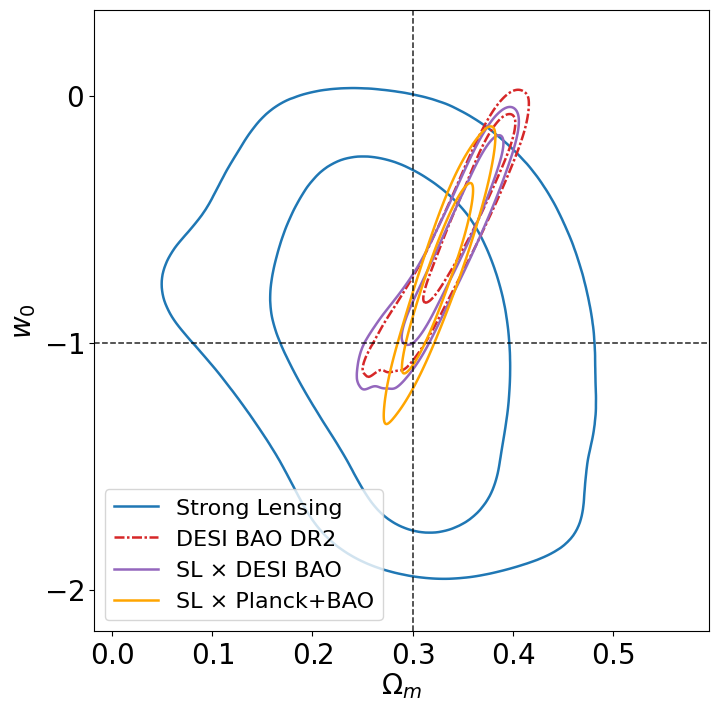

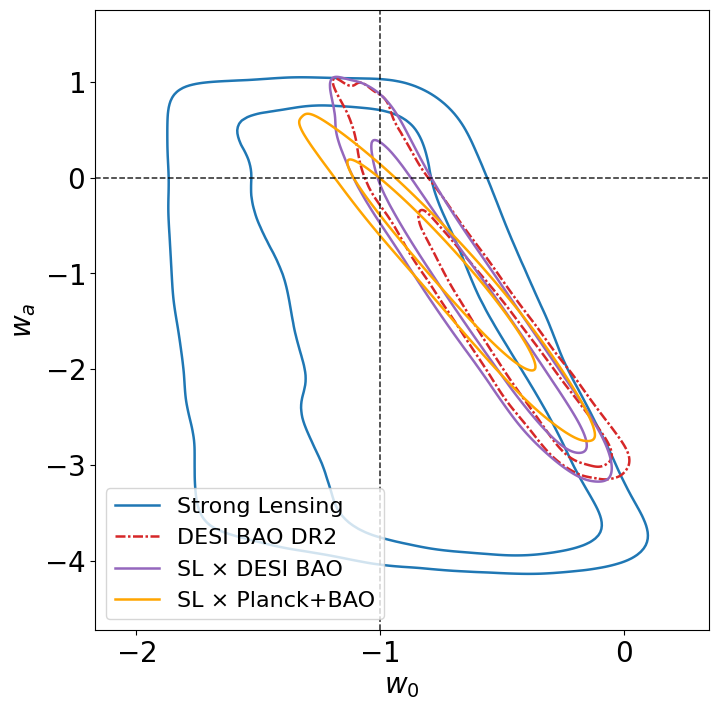

In [50]:
# joint3D_plots.py
# pip install getdist matplotlib scipy
import os, glob
import numpy as np
import matplotlib.pyplot as plt
from getdist.mcsamples import MCSamples, loadMCSamples
from getdist import plots
from scipy.stats import gaussian_kde

# ====================== 基础路径（按需修改） ======================
base_dir       = "/home/astrodust/SG/sgl_cosmo/GLS_cosmo01"
local_pairs    = [("linear", "Tri")]   # 本地 3D 链（含 omegam, w0, wa）
local_col_idx  = {'omegam': 0, 'w0': 1, 'wa': 2}
burnin_frac    = 0.30

# DESI BAO 文本链目录（含 Ωm, w0, wa）
desi_bao_folder = r"/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/DESI_BAO_base_w_wa/desi-bao-all"

# Planck+BAO（CosmoMC/GetDist 样式根路径，已经包含 BAO）
planck_base_dir   = "/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data"
planck_base_label = "base_w_wa"
planck_root_bao = os.path.join(
    planck_base_dir, planck_base_label,
    "plikHM_TTTEEE_lowl_lowE_BAO",
    f"{planck_base_label}_plikHM_TTTEEE_lowl_lowE_BAO"
)

# ====================== 工具函数：3D 链加载 ======================
def numpy3d_to_mcsamples_3D(arr, burnin_frac=0.3, col_idx=None, label=None):
    """
    从本地 (nwalk, nstep, ndim) 或 (N, ndim) 的数组取出 (omegam, w0, wa) 三列为 MCSamples。
    """
    if arr.ndim == 3:
        nwalk, nstep, ndim = arr.shape
        start = int(burnin_frac * nstep)
        flat = arr[:, start:, :].reshape(-1, ndim)
    else:
        flat = arr

    i_om = col_idx['omegam']; i_w0 = col_idx['w0']; i_wa = col_idx['wa']
    sub  = flat[:, [i_om, i_w0, i_wa]]

    mcs = MCSamples(
        samples=sub,
        names=['omegam','w0','wa'],
        labels=[r'\Omega_m', r'w_0', r'w_a']
    )
    if label:
        mcs.label = label
    mcs.updateSettings({'ignore_rows': 0.0})
    return mcs

def _getcol(a, *candidates):
    for name in candidates:
        if name in a.dtype.names:
            return a[name]
    return None

def load_desi_bao_3D(folder, label=r"DESI BAO DR2"):
    """
    读取 DESI BAO 文本链（chain.*.txt），抽取 (omegam, w0, wa) → 3D MCSamples。
    尝试兼容列名别名：
      Ωm:  omegam/omm/om/Omega_m/OmegaM
      w0:  w0/w/w_0
      wa:  wa/w_a/wprime/w_a_cpl
    """
    files = sorted(glob.glob(os.path.join(folder, "chain.*.txt")))
    if not files:
        raise FileNotFoundError("No chain.*.txt found under " + folder)
    parts = [np.genfromtxt(f, names=True, comments="#") for f in files]
    data  = np.concatenate(parts)

    Om  = _getcol(data, 'omegam', 'omm', 'om', 'Omega_m', 'OmegaM')
    w0  = _getcol(data, 'w0', 'w', 'w_0')
    wa  = _getcol(data, 'wa', 'w_a', 'wprime', 'w_a_cpl')

    if Om is None or w0 is None or wa is None:
        raise KeyError("DESI: 需要列 (omegam, w0, wa)，兼容别名 omm/om, w/w_0, w_a/wprime/w_a_cpl。")

    weights = _getcol(data, 'weight','weights','Weight','Weights')
    samples = np.vstack([Om, w0, wa]).T

    gd = MCSamples(samples=samples,
                   names=['omegam','w0','wa'],
                   labels=[r'\Omega_m', r'w_0', r'w_a'],
                   weights=weights if weights is not None else None)
    gd.updateSettings({'ignore_rows': 0.0})
    gd.label = label
    return gd

def ensure_3D_params_planck(samples):
    """
    Planck 链若字段名不同，统一提供 omegam / w0 / wa。
    """
    P = samples.getParams()
    names = {p.name for p in samples.getParamNames().names}

    # Ωm
    if 'omegam' not in names:
        cand = None
        for nm in ['omegam','om','Omega_m','OmegaM','omm']:
            if hasattr(P, nm):
                cand = getattr(P, nm)
                break
        if cand is None:
            raise RuntimeError("Planck 链中未找到 Ωm（omegam/om/Omega_m 等）。")
        samples.addDerived(cand, name='omegam', label=r'\Omega_m')
    else:
        try: samples.setLabel('omegam', r'\Omega_m')
        except: pass

    # w0
    if 'w0' not in names:
        if hasattr(P, 'w'):
            samples.addDerived(P.w, name='w0', label=r'w_0')
        elif hasattr(P, 'w0'):
            try: samples.setLabel('w0', r'w_0')
            except: pass
        else:
            raise RuntimeError("Planck 链未包含 w0/w。")
    else:
        try: samples.setLabel('w0', r'w_0')
        except: pass

    # wa
    if 'wa' not in names:
        if hasattr(P, 'wa'):
            samples.addDerived(P.wa, name='wa', label=r'w_a')
        else:
            raise RuntimeError("Planck 链未包含 wa。")
    else:
        try: samples.setLabel('wa', r'w_a')
        except: pass

    samples.updateSettings({'ignore_rows': 0.0})
    return samples

def make_joint_by_kde_3d(base_mcs, ref_mcs, names=('omegam','w0','wa'),
                         label='Joint3D', bw='scott'):
    """
    ref_mcs：比如 Strong Lensing
    base_mcs：比如 DESI BAO / Planck+BAO
    在 3D 空间 (Ωm, w0, wa) 上用 ref_mcs 的 KDE 给 base_mcs 重新加权。
    """
    P_base = base_mcs.getParams()
    base_arr = np.vstack([getattr(P_base, nm) for nm in names]).T  # (N_base, 3)

    P_ref = ref_mcs.getParams()
    ref_arr = np.vstack([getattr(P_ref, nm) for nm in names]).T    # (N_ref, 3)

    w_base = base_mcs.weights if base_mcs.weights is not None else np.ones(base_arr.shape[0])

    kde = gaussian_kde(ref_arr.T, bw_method=bw)
    dens = np.clip(kde(base_arr.T), 1e-300, None)
    w_joint = w_base * dens

    joint = MCSamples(
        samples=base_arr,
        names=list(names),
        labels=[r'\Omega_m', r'w_0', r'w_a'],
        weights=w_joint
    )
    joint.label = label
    joint.updateSettings({'ignore_rows': 0.0})
    return joint

def auto_limits_multi(samples_list, name, q=(0.5, 99.5), pad=0.15):
    vals = []
    for s in samples_list:
        try:
            arr = getattr(s.getParams(), name)
            vals.append(np.percentile(arr, q))
        except Exception:
            pass
    if not vals:
        return None
    vals = np.array(vals)
    lo, hi = np.min(vals[:, 0]), np.max(vals[:, 1])
    w = hi - lo
    return lo - pad*w, hi + pad*w

# ====================== 加载数据（3D） ======================
# Strong Lensing 3D
local_mcs = []
for evo, prior in local_pairs:
    f = os.path.join(base_dir, "Output", f"{evo}-{prior}", f"mcmc_cosmop3D-{evo}-{prior}.npy")
    if not os.path.isfile(f):
        raise FileNotFoundError("找不到本地链文件: " + f)
    arr = np.load(f)
    mcs = numpy3d_to_mcsamples_3D(
        arr,
        burnin_frac=burnin_frac,
        col_idx=local_col_idx,
        label=r"Strong Lensing"
    )
    local_mcs.append(mcs)
SL_full = local_mcs[0]

# DESI BAO 3D
DESI_full = load_desi_bao_3D(desi_bao_folder, label=r"DESI BAO DR2")

# Planck+BAO 3D（已经包含 BAO）
planck_full = loadMCSamples(planck_root_bao, settings={'ignore_rows': 0.3}, no_cache=True)
planck_full = ensure_3D_params_planck(planck_full)
planck_full.label = r"Planck+BAO"

# ====================== 3D 联合：SL × DESI / SL × Planck+BAO ======================
SLxDESI3D = make_joint_by_kde_3d(
    base_mcs=DESI_full,
    ref_mcs=SL_full,
    names=('omegam','w0','wa'),
    label=r"SL × DESI BAO",
    bw='scott'
)

SLxPlanck3D = make_joint_by_kde_3d(
    base_mcs=planck_full,
    ref_mcs=SL_full,
    names=('omegam','w0','wa'),
    label=r"SL × Planck+BAO",
    bw='scott'
)

# ====================== 画图 1：Ωm–w0 平面 ======================
# Strong lensing, DESI BAO, SL × DESI BAO, SL × Planck+BAO
to_plot_om_w0 = [SL_full, DESI_full, SLxDESI3D, SLxPlanck3D]
legend_labels_om_w0 = [s.label for s in to_plot_om_w0]

# 样式：SL(蓝实) / BAO(红-. ) / SL×BAO(紫实) / SL×Planck+BAO(橙实)
COL_SL   = '#1f77b4'
COL_BAO  = '#d62728'
COL_SLBAO= '#9467bd'
COL_SLPB = 'orange'

colors    = [COL_SL, COL_BAO, COL_SLBAO, COL_SLPB]
line_args = [
    {'ls': '-',  'lw': 1.8},   # SL
    {'ls': '-.', 'lw': 1.8},   # BAO
    {'ls': '-',  'lw': 1.8},   # SL×BAO
    {'ls': '-',  'lw': 1.8},   # SL×Planck+BAO
]

g = plots.get_subplot_plotter(width_inch=7.2)
g.settings.num_plot_contours = 2
g.settings.axes_fontsize = 20
g.settings.legend_fontsize = 16

g.plot_2d(
    to_plot_om_w0,
    ['omegam', 'w0'],
    filled=False,
    colors=colors,
    line_args=line_args,
    legend_labels=None,
)

ax = g.subplots[0, 0]
xlim = auto_limits_multi(to_plot_om_w0, 'omegam') or (0.15, 0.45)
ylim = auto_limits_multi(to_plot_om_w0, 'w0')     or (-1.6, -0.6)
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r'$\Omega_m$', fontsize=20)
ax.set_ylabel(r'$w_0$', fontsize=20)
# ax.set_title(r'$w_0w_a$CDM: $\Omega_m - w_0$', fontsize=15)

ax.axhline(-1.0, ls='--', lw=1.1, color='k', alpha=0.85)
ax.axvline(0.3,  ls='--', lw=1.1, color='k', alpha=0.85)

g.add_legend(legend_labels_om_w0, legend_loc='lower left', colored_text=False)

out1 = "joint3D_omegam_w0_SL_DESI_joint.png"
g.export(out1)
print(f"Saved plot: {out1}")

# ====================== 画图 2：w0–wa 平面 ======================
to_plot_w0_wa = [SL_full, DESI_full, SLxDESI3D, SLxPlanck3D]
legend_labels_w0_wa = [s.label for s in to_plot_w0_wa]

g2 = plots.get_subplot_plotter(width_inch=7.2)
g2.settings.num_plot_contours = 2
g2.settings.axes_fontsize = 20
g2.settings.legend_fontsize = 16

g2.plot_2d(
    to_plot_w0_wa,
    ['w0', 'wa'],
    filled=False,
    colors=colors,      # 同一套颜色和线型
    line_args=line_args,
    legend_labels=None,
)

ax2 = g2.subplots[0, 0]
xlim2 = auto_limits_multi(to_plot_w0_wa, 'w0') or (-1.6, -0.6)
ylim2 = auto_limits_multi(to_plot_w0_wa, 'wa') or (-3.5, 1.5)
ax2.set_xlim(*xlim2)
ax2.set_ylim(*ylim2)
ax2.set_xlabel(r'$w_0$', fontsize=20)
ax2.set_ylabel(r'$w_a$', fontsize=20)
# ax2.set_title(r'$w_0w_a$CDM: $w_0 - w_a$', fontsize=15)

ax2.axvline(-1.0, ls='--', lw=1.1, color='k', alpha=0.85)
ax2.axhline(0.0,  ls='--', lw=1.1, color='k', alpha=0.85)

g2.add_legend(legend_labels_w0_wa, legend_loc='lower left', colored_text=False)

out2 = "joint3D_w0_wa_SL_DESI_joint.png"
g2.export(out2)
print(f"Saved plot: {out2}")


In [49]:
# joint3D_stats.py
# pip install getdist scipy
import os, glob
import numpy as np
from getdist.mcsamples import MCSamples, loadMCSamples
from scipy.stats import gaussian_kde

# ====================== 基础路径（按需修改） ======================
base_dir       = "/home/astrodust/SG/sgl_cosmo/GLS_cosmo01"
local_pairs    = [("linear", "Tri")]   # 本地 3D 链（含 omegam, w0, wa）
local_col_idx  = {'omegam': 0, 'w0': 1, 'wa': 2}
burnin_frac    = 0.30

desi_bao_folder = r"/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/DESI_BAO_base_w_wa/desi-bao-all"

planck_base_dir   = "/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data"
planck_base_label = "base_w_wa"
planck_root_bao = os.path.join(
    planck_base_dir, planck_base_label,
    "plikHM_TTTEEE_lowl_lowE_BAO",
    f"{planck_base_label}_plikHM_TTTEEE_lowl_lowE_BAO"
)

# ====================== 链加载 & 3D 联合 ======================
def numpy3d_to_mcsamples_3D(arr, burnin_frac=0.3, col_idx=None, label=None):
    if arr.ndim == 3:
        nwalk, nstep, ndim = arr.shape
        start = int(burnin_frac * nstep)
        flat = arr[:, start:, :].reshape(-1, ndim)
    else:
        flat = arr

    i_om = col_idx['omegam']; i_w0 = col_idx['w0']; i_wa = col_idx['wa']
    sub  = flat[:, [i_om, i_w0, i_wa]]

    mcs = MCSamples(
        samples=sub,
        names=['omegam','w0','wa'],
        labels=[r'\Omega_m', r'w_0', r'w_a']
    )
    if label:
        mcs.label = label
    mcs.updateSettings({'ignore_rows': 0.0})
    return mcs

def _getcol(a, *candidates):
    for name in candidates:
        if name in a.dtype.names:
            return a[name]
    return None

def load_desi_bao_3D(folder, label=r"DESI BAO DR2"):
    files = sorted(glob.glob(os.path.join(folder, "chain.*.txt")))
    if not files:
        raise FileNotFoundError("No chain.*.txt found under " + folder)
    parts = [np.genfromtxt(f, names=True, comments="#") for f in files]
    data  = np.concatenate(parts)

    Om  = _getcol(data, 'omegam', 'omm', 'om', 'Omega_m', 'OmegaM')
    w0  = _getcol(data, 'w0', 'w', 'w_0')
    wa  = _getcol(data, 'wa', 'w_a', 'wprime', 'w_a_cpl')

    if Om is None or w0 is None or wa is None:
        raise KeyError("DESI: 需要列 (omegam, w0, wa)，兼容别名 omm/om, w/w_0, w_a/wprime/w_a_cpl。")

    weights = _getcol(data, 'weight','weights','Weight','Weights')
    samples = np.vstack([Om, w0, wa]).T

    gd = MCSamples(samples=samples,
                   names=['omegam','w0','wa'],
                   labels=[r'\Omega_m', r'w_0', r'w_a'],
                   weights=weights if weights is not None else None)
    gd.updateSettings({'ignore_rows': 0.0})
    gd.label = label
    return gd

def ensure_3D_params_planck(samples):
    P = samples.getParams()
    names = {p.name for p in samples.getParamNames().names}

    # Ωm
    if 'omegam' not in names:
        cand = None
        for nm in ['omegam','om','Omega_m','OmegaM','omm']:
            if hasattr(P, nm):
                cand = getattr(P, nm)
                break
        if cand is None:
            raise RuntimeError("Planck 链中未找到 Ωm（omegam/om/Omega_m 等）。")
        samples.addDerived(cand, name='omegam', label=r'\Omega_m')
    else:
        try: samples.setLabel('omegam', r'\Omega_m')
        except: pass

    # w0
    if 'w0' not in names:
        if hasattr(P, 'w'):
            samples.addDerived(P.w, name='w0', label=r'w_0')
        elif hasattr(P, 'w0'):
            try: samples.setLabel('w0', r'w_0')
            except: pass
        else:
            raise RuntimeError("Planck 链未包含 w0/w。")
    else:
        try: samples.setLabel('w0', r'w_0')
        except: pass

    # wa
    if 'wa' not in names:
        if hasattr(P, 'wa'):
            samples.addDerived(P.wa, name='wa', label=r'w_a')
        else:
            raise RuntimeError("Planck 链未包含 wa。")
    else:
        try: samples.setLabel('wa', r'w_a')
        except: pass

    samples.updateSettings({'ignore_rows': 0.0})
    return samples

def make_joint_by_kde_3d(base_mcs, ref_mcs, names=('omegam','w0','wa'),
                         label='Joint3D', bw='scott'):
    P_base = base_mcs.getParams()
    base_arr = np.vstack([getattr(P_base, nm) for nm in names]).T

    P_ref = ref_mcs.getParams()
    ref_arr = np.vstack([getattr(P_ref, nm) for nm in names]).T

    w_base = base_mcs.weights if base_mcs.weights is not None else np.ones(base_arr.shape[0])

    kde = gaussian_kde(ref_arr.T, bw_method=bw)
    dens = np.clip(kde(base_arr.T), 1e-300, None)
    w_joint = w_base * dens

    joint = MCSamples(
        samples=base_arr,
        names=list(names),
        labels=[r'\Omega_m', r'w_0', r'w_a'],
        weights=w_joint
    )
    joint.label = label
    joint.updateSettings({'ignore_rows': 0.0})
    return joint

# ====================== 1D 统计工具 ======================
def _normalize_weights(w):
    if w is None: return None
    w = np.asarray(w, float)
    s = np.sum(w)
    if s <= 0 or not np.isfinite(s): return None
    return w / s

def _weighted_quantile(x, q, w=None):
    x = np.asarray(x, float)
    if w is None:
        return np.quantile(x, q)
    w = np.asarray(w, float)
    s = np.argsort(x)
    xs, ws = x[s], w[s]
    cdf = np.cumsum(ws) / np.sum(ws)
    return np.interp(q, cdf, xs)

def _weighted_quantiles(x, qs, w=None):
    qs = np.atleast_1d(qs).astype(float)
    return np.array([_weighted_quantile(x, q, w) for q in qs])

def _weighted_median(x, w=None):
    return _weighted_quantile(x, 0.5, w)

def _weighted_mad(x, w=None, scale=1.4826):
    med = _weighted_median(x, w)
    return scale * _weighted_median(np.abs(x - med), w)

def _oned_peak(x, w=None, grids=2048):
    x = np.asarray(x, float)
    xmin, xmax = np.min(x), np.max(x)
    if not np.isfinite(xmin) or not np.isfinite(xmax) or xmin == xmax:
        return float(np.median(x))
    grid = np.linspace(xmin, xmax, grids)
    kde  = gaussian_kde(x, weights=_normalize_weights(w)) if w is not None else gaussian_kde(x)
    dens = kde(grid)
    return float(grid[np.argmax(dens)])

def _weighted_mean_sigma(x, w=None):
    x = np.asarray(x, float)
    if w is None:
        return float(np.mean(x)), float(np.std(x, ddof=0))
    wn = _normalize_weights(w)
    mu = float(np.sum(wn * x))
    sig = float(np.sqrt(np.sum(wn * (x - mu)**2)))
    return mu, sig

_ALIAS = {
    'omegam': ['omegam','om','Omega_m','OmegaM','omm'],
    'w0'    : ['w0','w','w_0'],
    'wa'    : ['wa','w_a','wprime','w_a_cpl']
}

def _get_param_array_with_alias(mcs, target):
    names = [p.name for p in mcs.getParamNames().names]
    if target in names:
        P = mcs.getParams()
        return np.asarray(getattr(P, target), float)
    for alt in _ALIAS.get(target, []):
        if alt in names:
            P = mcs.getParams()
            return np.asarray(getattr(P, alt), float)
    P = mcs.getParams()
    for alt in _ALIAS.get(target, []):
        if hasattr(P, alt):
            return np.asarray(getattr(P, alt), float)
    return None

def summarize_mcs_1dset(mcs, names=('omegam','w0','wa')):
    out = {}
    wts = None if mcs.weights is None else np.asarray(mcs.weights, float)
    for nm in names:
        arr = _get_param_array_with_alias(mcs, nm)
        if arr is None:
            out[nm] = None
            continue
        mean, sigma = _weighted_mean_sigma(arr, wts)
        med  = _weighted_median(arr, wts)
        mad  = _weighted_mad(arr, wts)
        pk   = _oned_peak(arr, wts)
        q16, q84 = _weighted_quantiles(arr, [0.16, 0.84], wts)
        out[nm] = dict(
            mean=mean, sigma=sigma,
            median=med, mad=mad,
            peak=pk, q16=q16, q84=q84,
            dmed_minus=med-q16, dmed_plus=q84-med
        )
    return out

def print_summary_1d(tag, summ, names=('omegam','w0','wa')):
    print(f"\n=== {tag} ===")
    for nm in names:
        s = summ.get(nm, None)
        if s is None:
            print(f"{nm:7s}: (N/A)")
            continue
        peak_txt   = f"peak = {s['peak']:.6f}"
        median_txt = (f"median = {s['median']:.6f} "
                      f"(q16={s['q16']:.6f}, q84={s['q84']:.6f}; "
                      f"Δ-={s['dmed_minus']:.6f}, Δ+={s['dmed_plus']:.6f}) "
                      f"(MAD={s['mad']:.6f})")
        mean_txt   = f"mean = {s['mean']:.6f}, sigma = {s['sigma']:.6f}"
        print(f"{nm:7s}: {peak_txt} | {median_txt} | {mean_txt}")

# ====================== 加载数据 & 构造 Joint3D ======================
# SL 3D
local_mcs = []
for evo, prior in local_pairs:
    f = os.path.join(base_dir, "Output", f"{evo}-{prior}", f"mcmc_cosmop3D-{evo}-{prior}.npy")
    if not os.path.isfile(f):
        raise FileNotFoundError("找不到本地链文件: " + f)
    arr = np.load(f)
    mcs = numpy3d_to_mcsamples_3D(
        arr,
        burnin_frac=burnin_frac,
        col_idx=local_col_idx,
        label=r"Strong Lensing"
    )
    local_mcs.append(mcs)
SL_full = local_mcs[0]

# DESI BAO 3D
DESI_full = load_desi_bao_3D(desi_bao_folder, label=r"DESI BAO DR2")

# Planck+BAO 3D
planck_full = loadMCSamples(planck_root_bao, settings={'ignore_rows': 0.3}, no_cache=True)
planck_full = ensure_3D_params_planck(planck_full)
planck_full.label = r"Planck+BAO"

# 3D 联合
SLxDESI3D = make_joint_by_kde_3d(
    base_mcs=DESI_full,
    ref_mcs=SL_full,
    names=('omegam','w0','wa'),
    label=r"SL × DESI BAO",
    bw='scott'
)

SLxPlanck3D = make_joint_by_kde_3d(
    base_mcs=planck_full,
    ref_mcs=SL_full,
    names=('omegam','w0','wa'),
    label=r"SL × Planck+BAO",
    bw='scott'
)

# ====================== 输出 1D 统计量 ======================
stats_targets = [
    (SL_full.label,     SL_full),
    (DESI_full.label,   DESI_full),
    (planck_full.label, planck_full),
    (SLxDESI3D.label,   SLxDESI3D),
    (SLxPlanck3D.label, SLxPlanck3D),
]

for tag, mcs in stats_targets:
    s = summarize_mcs_1dset(mcs, names=('omegam','w0','wa'))
    print_summary_1d(tag, s, names=('omegam','w0','wa'))


Removed no burn in
Removed no burn in
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_2.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_3.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_1.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_4.txt
Removed no burn in
Removed no burn in
Removed no burn in

=== Strong Lensing ===
omegam : peak = 0.279933 | median = 0.286130 (q16=0.204582, q84=0.370107; Δ-=0.081548, Δ+=0.083977) (MAD=0.083228) | mean = 0.286626, sigma = 0.086174
w0     : peak = -0.905031 | median = -0.940721 (q16=-1.443451, q84=-0.494801; Δ-=0.502730, Δ+=0.445920) (MAD=0.478171) | mean = -0.957948, sigma = 0.444868
wa     : peak = -3.525898 | median = -1.963675 (q16=-3.399313,

Removed no burn in
Saved plot: joint3D_w0_wa_SL_DESI_joint_with_DESI_CMB_DESY5.png


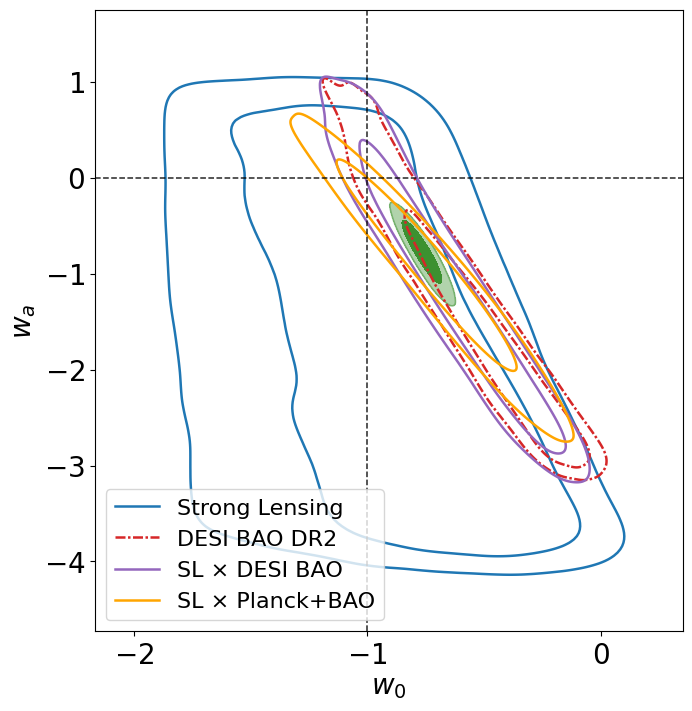

In [51]:
# ====================== 仅 w0–wa 平面画图（含 DESI+CMB+DESY5 填充） ======================
import os, glob
import numpy as np
from getdist import plots
from getdist.mcsamples import MCSamples

# 这里假定你已经有：
#   SL_full      = Strong Lensing 3D MCSamples（含 w0, wa）
#   DESI_full    = DESI BAO 3D MCSamples（含 w0, wa）
#   SLxDESI3D    = SL × DESI BAO 3D 联合后验
#   SLxPlanck3D  = SL × Planck+BAO 3D 联合后验
# 以及 auto_limits_multi(...) 函数已定义

# ---------- 工具：从 DESI+CMB+DESY5 文本链中抽取 (w0, wa) ----------
def _getcol(a, *candidates):
    for name in candidates:
        if name in a.dtype.names:
            return a[name]
    return None

def load_desi_cmb_desy5_w0wa(folder, label=r"DESI+CMB+DESY5"):
    """
    从 DESI+CMB+DESY5 的 chain.*.txt 中读取 (w0, wa) → MCSamples。
    """
    files = sorted(glob.glob(os.path.join(folder, "chain.*.txt")))
    if not files:
        raise FileNotFoundError("No chain.*.txt found under " + folder)
    parts = [np.genfromtxt(f, names=True, comments="#") for f in files]
    data  = np.concatenate(parts)

    w0 = _getcol(data, "w0", "w", "w_0")
    wa = _getcol(data, "wa", "w_a", "wprime", "w_a_cpl")
    if w0 is None or wa is None:
        raise KeyError("DESI+CMB+DESY5: 需要列 w0 和 wa（兼容别名：w/w_0, w_a/wprime/w_a_cpl）。")

    weights = _getcol(data, "weight", "weights", "Weight", "Weights")
    samples = np.vstack([w0, wa]).T

    mcs = MCSamples(
        samples=samples,
        names=["w0","wa"],
        labels=[r"w_0", r"w_a"],
        weights=weights if weights is not None else None
    )
    mcs.updateSettings({'ignore_rows': 0.0})
    mcs.label = label
    return mcs

# ---------- 加载 DESI+CMB+DESY5 ----------
desi_cmb_desy5_folder = (
    "/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/"
    "DESI_BAO_base_w_wa/"
    "desi-bao-all_desy5sn_planck2018-lowl-TT-clik_"
    "planck2020-lollipop-lowlE_planck2020-hillipop-TTTEEE_"
    "planck-act-dr6-lensing/"
)
DESI_CMB_DESY5 = load_desi_cmb_desy5_w0wa(desi_cmb_desy5_folder,
                                          label=r"DESI+CMB+DESY5")

# ---------- 要画的四条线状轮廓 ----------
to_plot_w0_wa = [SL_full, DESI_full, SLxDESI3D, SLxPlanck3D]
legend_labels_w0_wa = [s.label for s in to_plot_w0_wa]

# 样式：SL(蓝实) / BAO(红-. ) / SL×BAO(紫实) / SL×Planck+BAO(橙实)
COL_SL   = '#1f77b4'
COL_BAO  = '#d62728'
COL_SLBAO= '#9467bd'
COL_SLPB = 'orange'

colors    = [COL_SL, COL_BAO, COL_SLBAO, COL_SLPB]
line_args = [
    {'ls': '-',  'lw': 1.8},   # SL
    {'ls': '-.', 'lw': 1.8},   # BAO
    {'ls': '-',  'lw': 1.8},   # SL×BAO
    {'ls': '-',  'lw': 1.8},   # SL×Planck+BAO
]

# ---------- 画 w0–wa 平面 ----------
g2 = plots.get_subplot_plotter(width_inch=7.2)
g2.settings.num_plot_contours = 2
g2.settings.axes_fontsize = 20
g2.settings.legend_fontsize = 16

# 四组线状后验：不填充
g2.plot_2d(
    to_plot_w0_wa,
    ['w0', 'wa'],
    filled=False,
    colors=colors,
    line_args=line_args,
    legend_labels=None,
)

# 绿色填充的 DESI+CMB+DESY5，zorder 取最低（尽量压在最底下）
g2.plot_2d(
    DESI_CMB_DESY5,
    ['w0', 'wa'],
    filled=True,
    colors=['#3c9130'],        # 绿色
    add_legend_proxy=False,    # 不额外加 legend 项
    alpha=0.30,
    contour_args=[{'zorder': 0}],
    line_args=[{'zorder': 0}],
)

ax2 = g2.subplots[0, 0]
# 取所有 5 组的范围来设 axis limits，避免截掉绿色填充
all_for_limits = to_plot_w0_wa + [DESI_CMB_DESY5]
xlim2 = auto_limits_multi(all_for_limits, 'w0') or (-1.6, -0.6)
ylim2 = auto_limits_multi(all_for_limits, 'wa') or (-3.5, 1.5)
ax2.set_xlim(*xlim2)
ax2.set_ylim(*ylim2)
ax2.set_xlabel(r'$w_0$', fontsize=20)
ax2.set_ylabel(r'$w_a$', fontsize=20)
# ax2.set_title(r'$w_0w_a$CDM: $w_0 - w_a$', fontsize=15)

# 参考线：w0=-1, wa=0
ax2.axvline(-1.0, ls='--', lw=1.1, color='k', alpha=0.85)
ax2.axhline(0.0,  ls='--', lw=1.1, color='k', alpha=0.85)

# 只给四条线的 legend（不包括绿色填充 DESI+CMB+DESY5）
g2.add_legend(legend_labels_w0_wa, legend_loc='lower left', colored_text=False)

out2 = "joint3D_w0_wa_SL_DESI_joint_with_DESI_CMB_DESY5.png"
g2.export(out2)
print(f"Saved plot: {out2}")


/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_2.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_3.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_1.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_4.txt
Removed no burn in
Removed no burn in
Removed no burn in
Saved: combined_w0_wa_planckBAO_vs_local3D.png


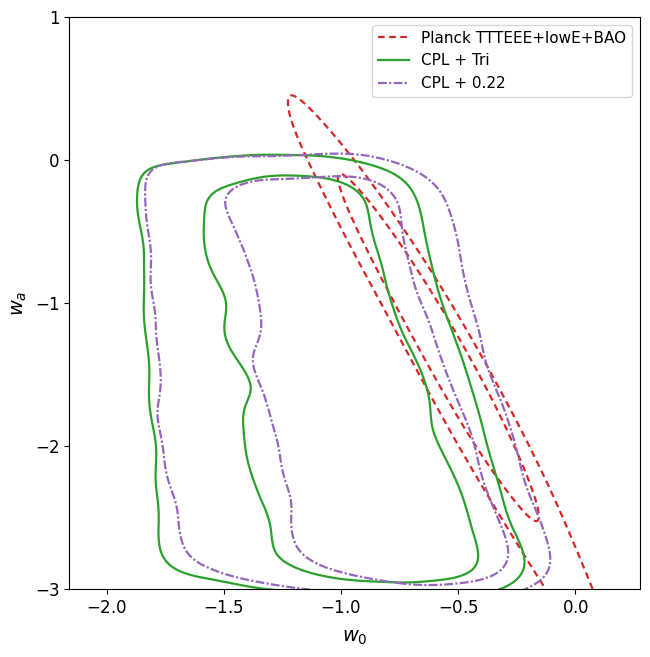

In [8]:
# pip install getdist matplotlib
import os
import numpy as np
from getdist.mcsamples import loadMCSamples, MCSamples
from getdist import plots

# ---------------- Planck 链（w0–wa 模型） ----------------
# 典型目录名为 base_w_wa；若你的目录名不同，改 planck_base_label
planck_base_dir   = "/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data"
planck_base_label = "base_w_wa"

planck_root_bao = os.path.join(
    planck_base_dir, planck_base_label,
    "plikHM_TTTEEE_lowl_lowE_BAO",
    f"{planck_base_label}_plikHM_TTTEEE_lowl_lowE_BAO"
)
# 若要带 CMB lensing，把上面 root 改为 *_post_lensing

# ---------------- 本地 3D 链（含 Ωm, w0, wa） ----------------
base_dir     = "/home/astrodust/SG/sgl_cosmo/GLS_cosmo01"
local_pairs  = [("CPL", "Tri"), ("CPL", "0.22")]   # 两条本地链
# 指明本地数组列索引：假设为 (Ωm, w0, wa) -> 分别是 0,1,2
local_col_idx = {'omegam': 0, 'w0': 1, 'wa': 2}
burnin_frac   = 0.30

# ---------------- 工具函数 ----------------
def ensure_w0_wa(samples):
    """
    确保 Planck 样本里有 w0 与 wa。
    部分 Planck 链把 w0 记作 w，这里自动映射成 w0。
    同时设置 GetDist 内部标签（不带 $）。
    """
    P = samples.getParams()
    names = {p.name for p in samples.getParamNames().names}

    # w0
    if 'w0' not in names:
        if hasattr(P, 'w'):
            samples.addDerived(P.w, name='w0', label=r'w_0')
        elif hasattr(P, 'w0'):
            pass
        else:
            raise RuntimeError("未在 Planck 链中找到 w 或 w0。请确认使用的是 w0–wa 模型链（如 base_w_wa）。")

    # wa
    if 'wa' not in names:
        if hasattr(P, 'wa'):
            pass
        else:
            raise RuntimeError("未在 Planck 链中找到 wa。请确认使用的是 w0–wa 模型链。")

    # 统一标签（GetDist 标签不要加 $）
    try: samples.setLabel('w0', r'w_0')
    except: pass
    try: samples.setLabel('wa', r'w_a')
    except: pass
    return samples

def numpy3d_to_mcsamples_w0wa(arr, burnin_frac=0.3, col_idx=None, label=None):
    """
    将本地 numpy 链 (可为 (nwalkers,nsteps,ndim) 或 (nsamp,ndim)) 提取 w0–wa，
    打包成 getdist.MCSamples。
    col_idx: {'omegam':i0,'w0':i1,'wa':i2}，只会用到 'w0' 和 'wa'。
    """
    if arr.ndim == 3:
        nwalk, nstep, ndim = arr.shape
        start = int(burnin_frac * nstep)
        flat = arr[:, start:, :].reshape(-1, ndim)
    else:
        flat = arr
        ndim = flat.shape[-1]

    i_w0 = col_idx['w0']
    i_wa = col_idx['wa']
    sub  = flat[:, [i_w0, i_wa]]  # 只要 (w0, wa)

    names  = ['w0', 'wa']          # 内部代号
    labels = [r'w_0', r'w_a']      # GetDist 标签（不带 $）
    mcs = MCSamples(samples=sub, names=names, labels=labels)
    if label:
        mcs.label = label
    return mcs

def auto_limits_multi(samples_list, name, q=(0.5, 99.5), pad=0.15):
    """汇总多组样本的分位数范围，返回统一坐标轴范围（增加边距）"""
    vals = []
    for s in samples_list:
        try:
            arr = getattr(s.getParams(), name)
            vals.append(np.percentile(arr, q))
        except Exception:
            pass
    if not vals:
        return None
    vals = np.array(vals)
    lo, hi = np.min(vals[:, 0]), np.max(vals[:, 1])
    w = hi - lo
    return lo - pad*w, hi + pad*w

# ---------------- 加载 Planck (TTTEEE+lowE+BAO) ----------------
planck_bao = loadMCSamples(planck_root_bao, settings={'ignore_rows': 0.3}, no_cache=True)
planck_bao = ensure_w0_wa(planck_bao)
planck_bao.label = r'Planck TTTEEE+lowE+BAO'

# ---------------- 加载本地 3D 链（linear + Tri / 0.22） ----------------
local_mcs = []
for evo, prior in local_pairs:
    f = os.path.join(base_dir, "Output", f"{evo}-{prior}", f"mcmc_cosmop3D-{evo}-{prior}.npy")
    if not os.path.isfile(f):
        raise FileNotFoundError(f"找不到本地链文件: {f}")
    arr = np.load(f)
    mcs = numpy3d_to_mcsamples_w0wa(arr, burnin_frac=burnin_frac,
                                    col_idx=local_col_idx,
                                    label=f"{evo} + {prior}")
    local_mcs.append(mcs)

# ---------------- 画 w0–wa，三套等高线 ----------------
all_samples = [planck_bao] + local_mcs
legend_labels = [s.label for s in all_samples]

colors = ['#d62728', '#2ca02c', '#9467bd']  # 红 / 绿 / 紫
line_args = [
    {'ls': '--', 'lw': 1.6},  # Planck + BAO
    {'ls': '-',  'lw': 1.6},  # linear + Tri
    {'ls': '-.', 'lw': 1.6},  # linear + 0.22
]

g = plots.get_subplot_plotter(width_inch=6.6)
g.settings.num_plot_contours = 2
g.settings.axes_fontsize = 12
g.settings.legend_fontsize = 11

g.plot_2d(
    all_samples,
    ['w0', 'wa'],
    filled=False,
    colors=colors,
    line_args=line_args,
    legend_labels=legend_labels,
)

# 坐标轴范围与标签（Matplotlib 端加 $...$）
ax = g.subplots[0, 0]
xlim = auto_limits_multi(all_samples, 'w0') or (-2.5, -0.3)
# ylim = auto_limits_multi(all_samples, 'wa') or (-2.5, 2.5)
ylim = (-3, 1.)
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r'$w_0$')
ax.set_ylabel(r'$w_a$')

g.add_legend(legend_labels,
             legend_loc='upper right', colored_text=False)

out = "combined_w0_wa_planckBAO_vs_local3D.png"
g.export(out)
print(f"Saved: {out}")
